## Домашка 2
<h4><em>«Одно Кольцо, чтоб править всеми,<br>
Одно Кольцо, чтоб всех найти,<br>
Одно Кольцо, чтоб собрать всех в тени<br>
И заковать их всех во Тьме»</em><br>
— <em>Властелин колец</em>
</h4>

Эта домашка про приоритизацию метрик. За неё можно получить максимум 12 баллов. 

**Дедлайны**   
Мягкий дедлайн: 27.09.2026 23:59 по МСК.   
Жесткий дедлайн: 04.10.2026 23:59 по МСК.

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.
После жесткого дедлайна работы не принимаются.

**Правила сдачи**  
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

**Использование ИИ**

- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_2). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip)

In [666]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.style.use('seaborn-v0_8-whitegrid')

### Warm up

#### 1. Game dev — 2 балла
У вас есть данные о событиях в мобильной игре. Рассчитайте и визуализируйте:
- User Stickiness — отношение DAU к MAU (MAU рассчитывайте скользящим окном 30 дней для каждой даты только для полного окна)
- ARPDAU
- Paying Share — доля платящих пользователей
- Sessions per User — среднее число сессий на пользователя
- Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
- Avg Attempts per Session — среднее число попыток на сессию

*Смотрим на подневную динамику

In [667]:
df_game = pd.read_csv('data/hw_2_gamedev.csv', index_col=0)
df_game.head()

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871


Описание данных (уникальный ключ session_id)

- session_id — уникальный идентификатор сессии
- user — уникальный идентификатор юзера
- date — дата 
- revenue — суммарная выручка на сессию
- attempts — число попыток на сессию
- session_length_sec — длина сессии в секундах

In [668]:
df_game.isna().sum() #Ангелина пояснила, что за активность принимает просто не нулевую сессию, таким образом, все записи пойдут в расчет метрик. 

session_id                  0
user                        0
date                        0
revenue               3051512
attempts               191330
session_length_sec          0
dtype: int64

In [669]:
# your code is here

df_game.fillna(0, inplace=True) 
df_game['date']=pd.to_datetime(df_game['date'])

In [670]:
#создаю датасет периода без пропусков дней для расчета метрик
dates=pd.DataFrame({'date':pd.date_range(df_game['date'].min(), df_game['date'].max())})

In [671]:
#расчет dau и мерж с датасетом периода:
dates=dates.merge(df_game[['date', 'user']].drop_duplicates().groupby('date', as_index=False).user.nunique().rename(columns={'user': 'dau'}), how='left', on='date')
dates.head(3)

,date,dau
0,2022-11-02,18710
1,2022-11-03,48669
2,2022-11-04,60913


In [672]:
#расчет mau как количество уникальных пользователей за 30 предыдущих дней от даты расчета:
dates['mau']=dates['date'].apply(lambda date: df_game.loc[(df_game['date']>=date-pd.Timedelta(days=29)) & (df_game['date']<=date), 'user'].nunique())
dates.loc[dates['date']<df_game['date'].min()+pd.Timedelta(days=29), 'mau']=np.nan
dates.head(3)

,date,dau,mau
0,2022-11-02,18710,NaN
1,2022-11-03,48669,NaN
2,2022-11-04,60913,NaN


In [673]:
#расчет первой метрики - User Stickness
dates['user_stickiness']=dates['dau']/dates['mau']
dates.tail()

,date,dau,mau,user_stickiness
60,2023-01-01,13868,54833.0,0.252913
61,2023-01-02,12667,54001.0,0.234570
62,2023-01-03,9204,52973.0,0.173749
63,2023-01-04,6434,52163.0,0.123344
64,2023-01-05,3250,51317.0,0.063332


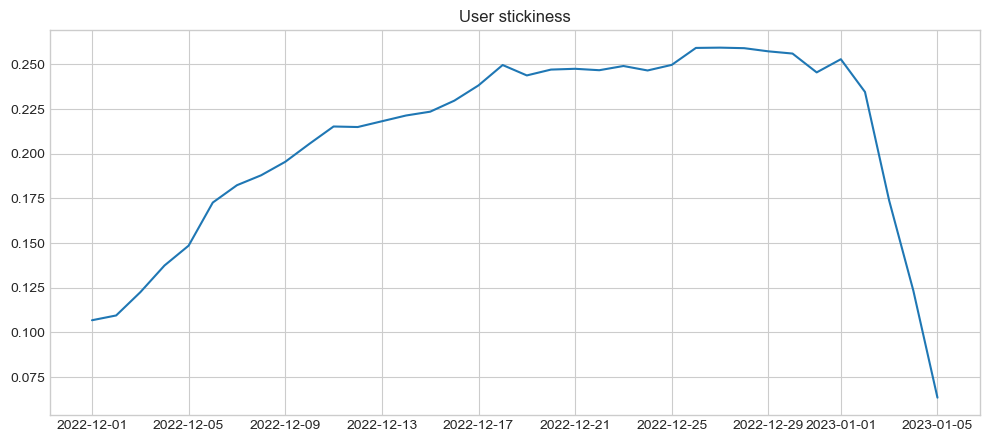

In [674]:
plt.figure(figsize=(12,5))
sns.lineplot(data=dates, x='date', y='user_stickiness')
plt.xlabel('')
plt.ylabel('')
plt.title('User stickiness')
plt.show()

In [675]:
#расчет ARPDAU - средняя выручка на одного пользователя за день, то есть сумма выручки за день/количество уникальных пользователей за день
dates['ARPDAU']=df_game.groupby(['date'], as_index=False).revenue.sum()['revenue']/dates['dau']
dates.head(3)

,date,dau,mau,user_stickiness,ARPDAU
0,2022-11-02,18710,NaN,NaN,0.019312
1,2022-11-03,48669,NaN,NaN,0.063400
2,2022-11-04,60913,NaN,NaN,0.081525


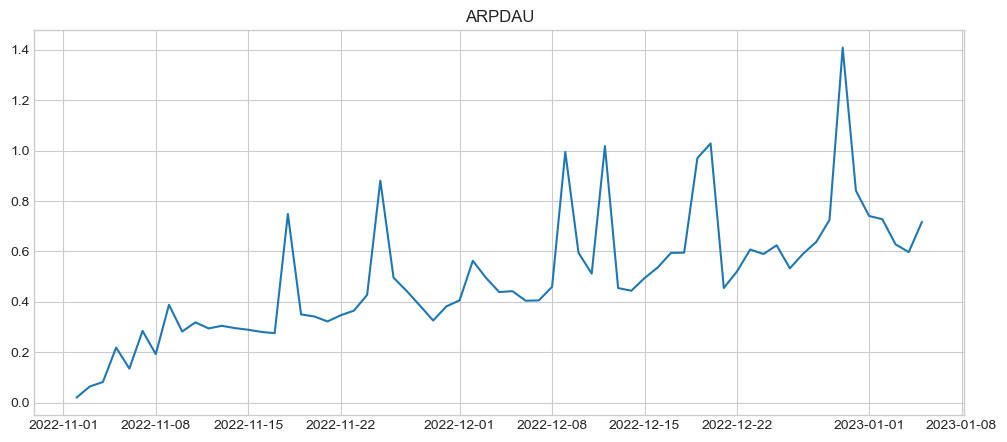

In [676]:
plt.figure(figsize=(12,5))
sns.lineplot(data=dates, x='date', y='ARPDAU')
plt.xlabel('')
plt.ylabel('')
plt.title('ARPDAU')
plt.show()

In [677]:
#расчет Paying Share — доля платящих пользователей:
dates['paying_share']=df_game.query('revenue>0').groupby(['date'], as_index=False).user.nunique()['user']/dates['dau']
dates.head(3)

,date,dau,mau,user_stickiness,ARPDAU,paying_share
0,2022-11-02,18710,NaN,NaN,0.019312,0.001122
1,2022-11-03,48669,NaN,NaN,0.063400,0.002856
2,2022-11-04,60913,NaN,NaN,0.081525,0.004597


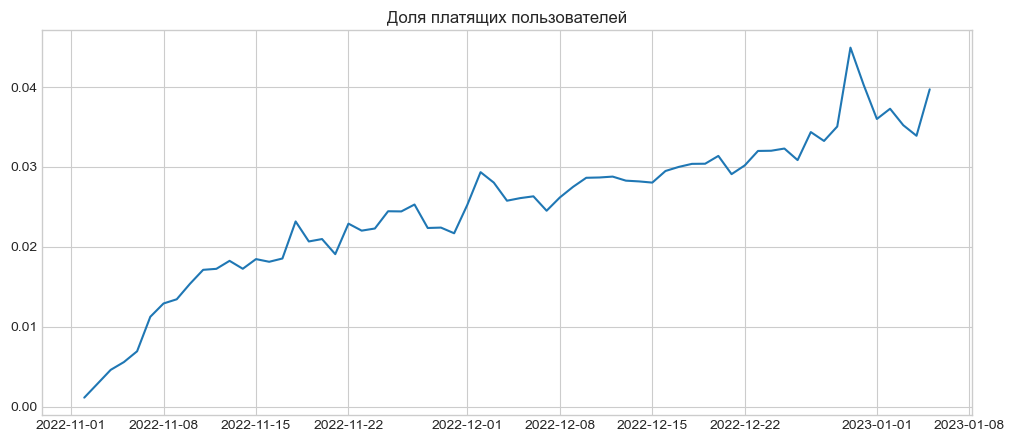

In [678]:
plt.figure(figsize=(12,5))
sns.lineplot(data=dates, x='date', y='paying_share')
plt.xlabel('')
plt.ylabel('')
plt.title('Доля платящих пользователей')
plt.show()

In [679]:
#Расчет метрики Sessions per User — среднее число сессий на пользователя
dates['session_per_user']=df_game.groupby(['date'], as_index=False).session_id.nunique()['session_id']/dates['dau']

#Расчет метрики Daily Play Time — среднее время, проводимое пользователем в игре в день
dates['daily_play_time']=df_game.groupby(['date'], as_index=False).session_length_sec.sum()['session_length_sec']/dates['dau']

#Расчет метрики Avg Attempts per Session — среднее число попыток на сессию. 
dates['avg_attempts_per_session']=df_game.groupby(['date'], as_index=False).attempts.mean()['attempts']

In [680]:
dates.tail(6)

,date,dau,mau,user_stickiness,ARPDAU,paying_share,session_per_user,daily_play_time,avg_attempts_per_session
59,2022-12-31,13591,55353.0,0.245533,0.840787,0.040247,2.052535,8348.972408,33.897184
60,2023-01-01,13868,54833.0,0.252913,0.740264,0.035982,2.048241,7755.253389,31.509297
61,2023-01-02,12667,54001.0,0.234570,0.727561,0.037262,2.058025,7868.969369,31.858816
62,2023-01-03,9204,52973.0,0.173749,0.627782,0.035202,2.045524,6963.151999,28.532179
63,2023-01-04,6434,52163.0,0.123344,0.596896,0.033882,2.036058,6565.358253,26.729818
64,2023-01-05,3250,51317.0,0.063332,0.717151,0.039692,2.044923,7308.699692,29.563184


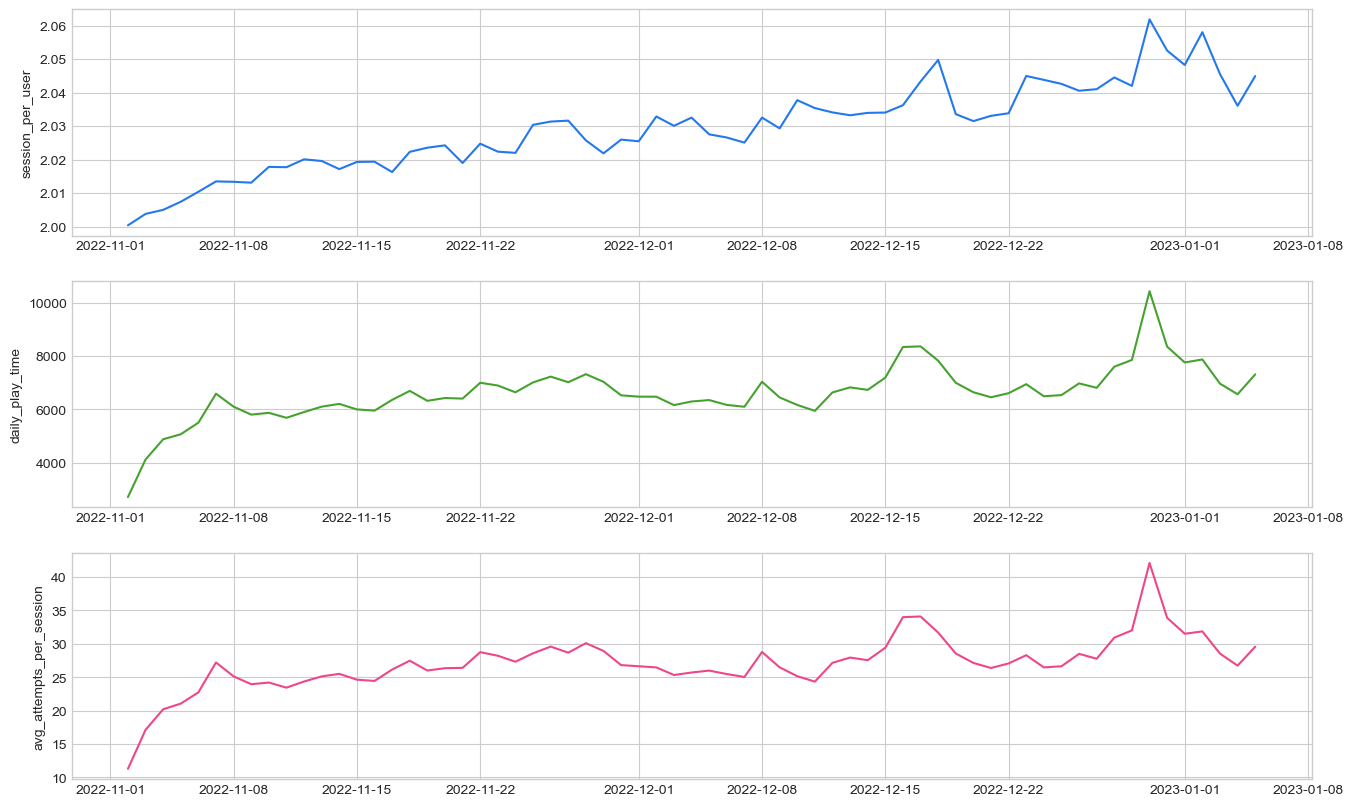

In [681]:
fig, ax = plt.subplots(3,1, figsize=(16,10))

sns.lineplot(data=dates, x='date', y='session_per_user', ax=ax[0], color="#2378EF", linewidth=1.5)
sns.lineplot(data=dates, x='date', y='daily_play_time', ax=ax[1], color="#46A22F", linewidth=1.5)
sns.lineplot(data=dates, x='date', y='avg_attempts_per_session', ax=ax[2], color="#EF468A", linewidth=1.5)
for ax in ax:
    ax.set_xlabel('')
plt.show()

#### 2. Ride hailing  — 2 балла
У вас есть данные из приложения такси. Рассчитайте и визуализируйте:
- Ride Completion Rate — CR из заказа в завершенную поездку
- Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
- Cancellation Rate — доля отмененных заказов
- Rides per Driver — среднее число поездок на водителя (по завершенным заказам)
- Avg Ride Check — средний чек поездки (update от Ангелины: по завершенным заказам)
- Отношение RTA к ETA (что измеряет эта метрика?) (update от Ангелины: для поездки оба поле должны быть не NaN)

*Смотрим на подневную динамику

In [682]:
df_rh = pd.read_csv('data/hw_2_taxi.csv')
df_rh.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Описание данных (уникальный ключ order_uid)

- date — дата создания заказа
- time — время создания заказа
- order_uid — уникальный идентификатор заказа
- order_status — статус заказа
- passenger_id — уникальный идентификатор пассажира
- vehicle_type — тип транспорта 
- pickup_location — место отправления
- drop_location — место назначения
- ETA — прогнозное время прибытия водителя на место отправления (estimated time of arrival)
- RTA — реальное время прибытия водителя на место отправления (real time of arrival)
- driver_id — уникальный идентификатор водителя
- cancelled_rides_by_customer — флаг отмены поездки пассажиром
- reason_for_cancelling_by_customer — причина отмены поездки пассажиром
- cancelled_rides_by_driver — флаг отмены поездки водителем
- driver_cancellation_reason — причина отмены поездки водителем
- incomplete_rides — флаг незавершенной поездки
- incomplete_rides_reason — причина незавершенной поездки
- fare — цена поездки
- ride_distance – расстояние поездки
- driver_ratings — рейтинг водителя
- customer_rating — рейтинг пассажира
- payment_method – способ оплаты

In [683]:
#считаю уникальное количество событий на каждый день:
df_metrics=df_rh.pivot_table(index='date', columns='order_status', values='order_uid', aggfunc='nunique', margins=True)
df_metrics.head()

order_status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found,All
date,,,,,,
2024-01-01,25,94,251,21,23,414
2024-01-02,31,68,240,18,32,389
2024-01-03,20,75,245,24,20,384
2024-01-04,31,73,254,27,29,414
2024-01-05,28,72,257,25,34,416


In [684]:
#Расчет Ride Completion Rate — CR из заказа в завершенную поездку:
df_metrics['Ride_Completion_Rate']=(df_metrics['Completed']*100/df_metrics['All']).round(2)

#Расчет Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
df_metrics['Acceptance_Rate']=((1-df_metrics['No Driver Found']/df_metrics['All'])*100).round(2)

#Расчет Cancellation Rate — доля отмененных заказов, учитывая отмены водителей и клиентов:
df_metrics['Cancellation_Rate']=(((df_metrics['Cancelled by Customer']+df_metrics['Cancelled by Driver'])/df_metrics['All'])*100).round(2)

#Расчет Rides per Driver — среднее число поездок на водителя (по завершенным заказам)
df_metrics['Rides_per_Driver']=(df_metrics['Completed']/df_rh.query('order_status == "Completed"').groupby('date').driver_id.nunique()).round(2)

# Avg Ride Check — средний чек поездки (по завершенным заказам):
df_metrics['Avg Ride Check']=(df_rh.query('order_status=="Completed"').groupby('date').fare.sum()/df_metrics['Completed']).round(2)

df_metrics.head(3)

order_status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found,All,Ride_Completion_Rate,Acceptance_Rate,Cancellation_Rate,Rides_per_Driver,Avg Ride Check
date,,,,,,,,,,,
2024-01-01,25,94,251,21,23,414,60.63,94.44,28.74,3.92,459.16
2024-01-02,31,68,240,18,32,389,61.70,91.77,25.45,4.14,444.03
2024-01-03,20,75,245,24,20,384,63.80,94.79,24.74,4.22,435.67


In [685]:
#Расчет отношения RTA к ETA:
RTA_to_ETA=df_rh[['date', 'RTA', 'ETA']].query('ETA.notna() and RTA.notna()') 
RTA_to_ETA['RTA/ETA']=RTA_to_ETA['RTA']/RTA_to_ETA['ETA']
df_metrics['daily_RTA_to_ETA']=RTA_to_ETA.groupby('date')['RTA/ETA'].mean().round(2)
df_metrics.head(3)

order_status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found,All,Ride_Completion_Rate,Acceptance_Rate,Cancellation_Rate,Rides_per_Driver,Avg Ride Check,daily_RTA_to_ETA
date,,,,,,,,,,,,
2024-01-01,25,94,251,21,23,414,60.63,94.44,28.74,3.92,459.16,1.32
2024-01-02,31,68,240,18,32,389,61.70,91.77,25.45,4.14,444.03,1.35
2024-01-03,20,75,245,24,20,384,63.80,94.79,24.74,4.22,435.67,1.33


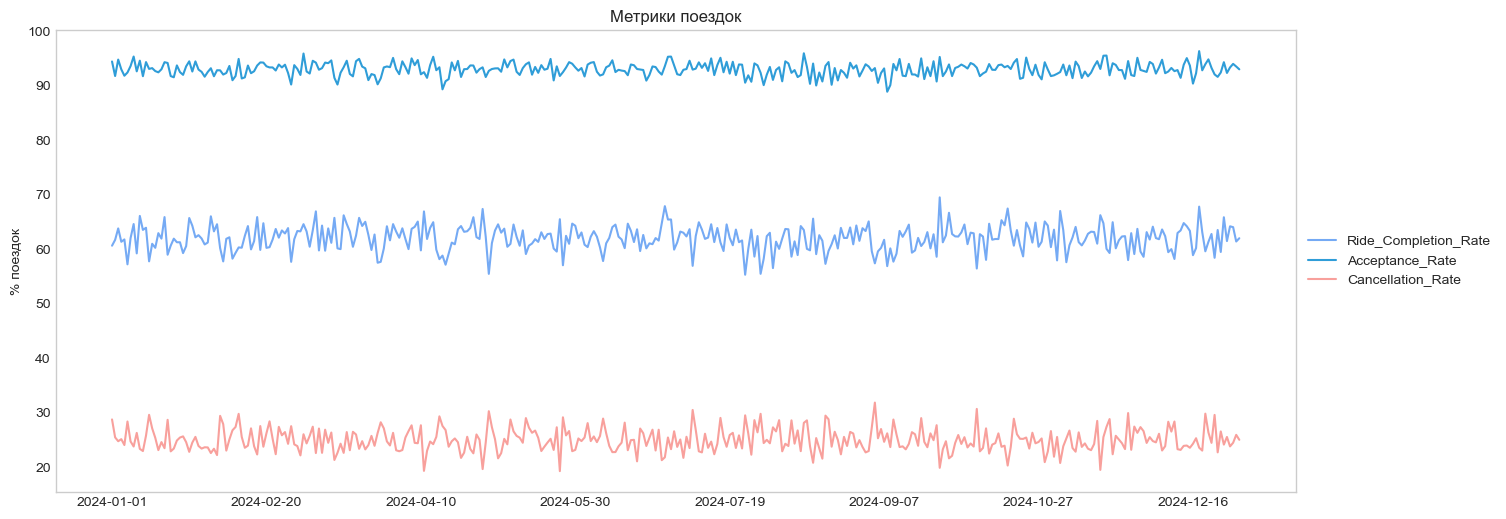

In [686]:
fig, ax = plt.subplots(figsize=(16,6))

sns.lineplot(data=df_metrics, x='date', y='Ride_Completion_Rate', ax=ax, color="#75AAF4", linewidth=1.5, label='Ride_Completion_Rate')
sns.lineplot(data=df_metrics, x='date', y='Acceptance_Rate', ax=ax, color="#2F9DD8", linewidth=1.5, label='Acceptance_Rate')
sns.lineplot(data=df_metrics, x='date', y='Cancellation_Rate', ax=ax,  color="#F8A09C", linewidth=1.5, label='Сancellation_Rate')

plt.xlabel('')
plt.ylabel('% поездок')
plt.title('Метрики поездок')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.grid(False)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

plt.show()

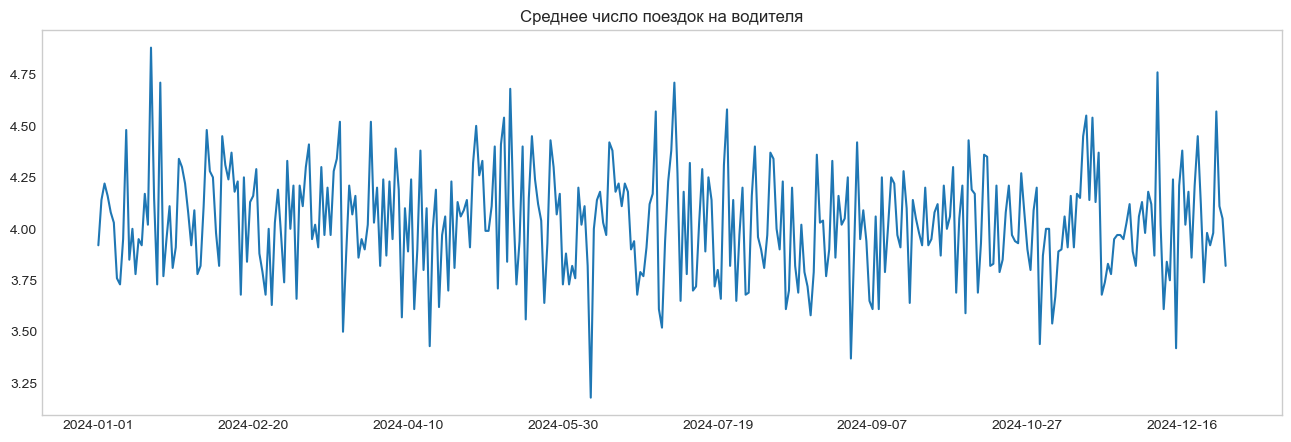

In [687]:
fig, ax = plt.subplots(figsize=(16,5))
sns.lineplot(data=df_metrics, x='date', y='Rides_per_Driver', linewidth=1.5, ax=ax)
plt.title('Среднее число поездок на водителя')
plt.grid(False)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.xlabel('')
plt.ylabel('')
plt.show()

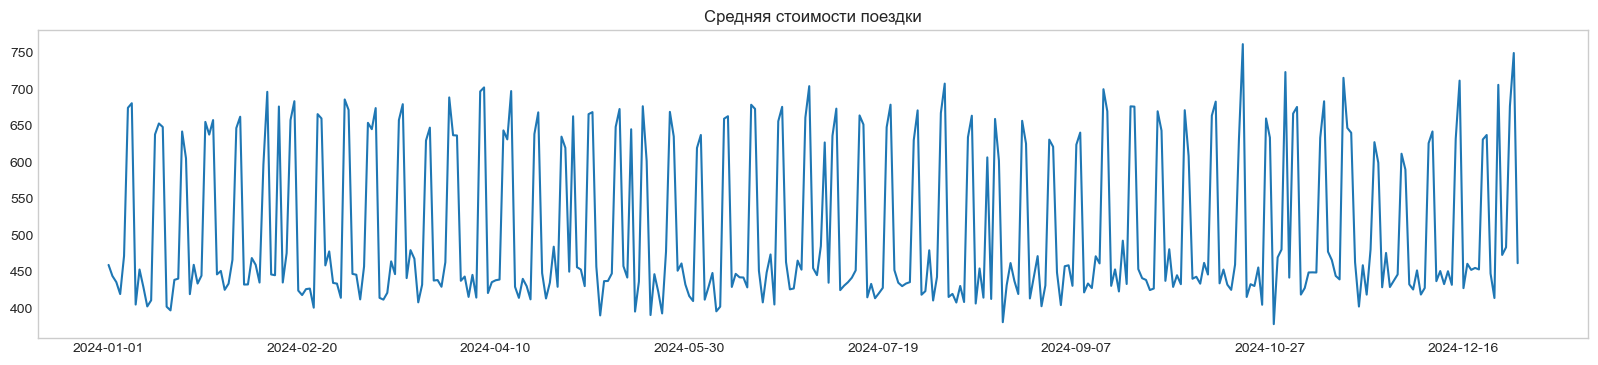

In [688]:
fig, ax = plt.subplots(figsize=(20,4))
sns.lineplot(data=df_metrics, x='date', y='Avg Ride Check', linewidth=1.5, ax=ax)
plt.title('Средняя стоимости поездки')
plt.grid(False)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.xlabel('')
plt.ylabel('')
plt.show()

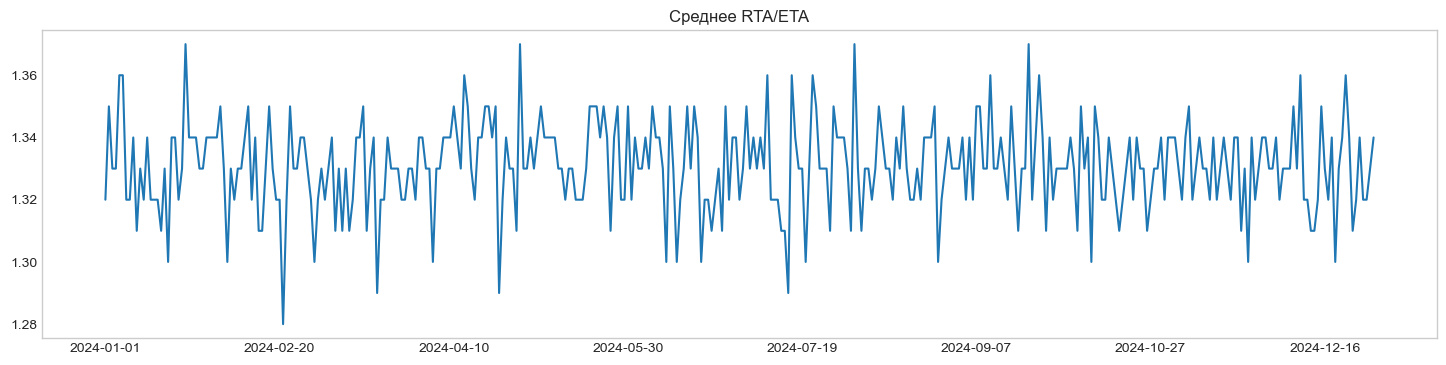

In [689]:
fig, ax = plt.subplots(figsize=(18,4))
sns.lineplot(data=df_metrics, x='date', y='daily_RTA_to_ETA', linewidth=1.5, ax=ax)
plt.title('Среднее RTA/ETA')
plt.grid(False)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.xlabel('')
plt.ylabel('')
plt.show()

**Отношение RTA/ETA показывает во сколько раз реальное ожидание прибытия водителя отличается от прогнозируемого. В зависимости от дня среднее RTA/ETA составляет примерно 1.28–1.37. Таким образом, фактическое время ожидания прибытия водителя в среднем составляло 128% от прогнозируемого, то есть было на 28% больше ETA.**

### Case Study. Запуск подкастов в стриминговом сервисе 🎧

**Легенда**  
Вы работаете продуктовым аналитиком в музыкальном стриминговом сервисе. Недавно в продукте запустился раздел с подкастами. Команда, отвечающая за запуск, хочет понять, стоит ли масштабировать и продвигать этот формат.

In [690]:
df_music_logs = pd.read_parquet('data/hw_2_streaming_logs.pqt')
df_music_subs = pd.read_parquet('data/hw_2_streaming_subs.pqt')

In [691]:
df_music_logs.head()

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0


In [692]:
df_music_subs.head()

,uid,start_date,end_date
0,600,2024-08-08,NaT
1,700,2024-03-29,NaT
2,800,2024-06-13,NaT
3,1100,2024-11-19,NaT
4,1400,2024-12-01,NaT


Описание данных hw_2_streaming_logs:

- datetime — дата-время взаимодействия с контентом
- uid — уникальный идентификатор пользователя
- item_id — уникальный идентификатор трека/эпизода
- played_ratio_pct — процент от длительности, который был воспроизведен
- track_length_seconds – длина трека/эпизода в секундах
- content_type — тип контента: музыка или подкаст
- is_first_date — флаг, является ли эта дата первой для пользователя в продукте

Описание данных hw_2_streaming_subs:

- uid — уникальный идентификатор пользователя
- start_date — дата начала подписки
- end_date — дата окончания подписки

#### 3. Метрики роста  — 2 балла

Рассчитайте и визуализируйте:
- DAU, MAU, WAU;
- Количество новых премиум-подписчиков (за неделю и месяц);
- Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).

Сделайте выводы:
- Есть ли выраженный тренд?
- Нет ли подозрений, что с раскаткой раздела что-то могло пойти не так (изменение тренда, выраженные ступеньки)?
- Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?

##### 3.1 Расчет DAU, MAU, WAU

In [693]:
# your code is here

df_music_logs['date']=df_music_logs['datetime'].dt.normalize()

#датафрейм, в который буду записывать рассчитанные метрики
user_activity_metrics=pd.DataFrame({'date': pd.date_range(df_music_logs.date.min(), df_music_logs.date.max())})
user_activity_metrics.head(3)

,date
0,2024-01-13
1,2024-01-14
2,2024-01-15


In [694]:
# добавляю колонку с началом недели и месяца
df_music_logs['week']=df_music_logs['date'].dt.to_period('W').dt.to_timestamp()
df_music_logs['month']=df_music_logs['date'].dt.to_period('M').dt.to_timestamp()

df_music_subs['start_week']=df_music_subs['start_date'].dt.to_period('W').dt.to_timestamp()
df_music_subs['start_month']=df_music_subs['start_date'].dt.to_period('M').dt.to_timestamp()
df_music_subs['end_week']=df_music_subs['end_date'].dt.to_period('W').dt.to_timestamp()
df_music_subs['end_month']=df_music_subs['end_date'].dt.to_period('M').dt.to_timestamp()

In [695]:
#сокращенный датафрем для расчета некоторых метрик
df_logs_short=df_music_logs[['date', 'uid']].drop_duplicates().sort_values(by='date')
df_logs_short.head(3)

,date,uid
0,2024-01-13,468300
30351,2024-01-13,983900
30326,2024-01-13,81000


In [696]:
#Расчет метрик DAU/WAU/MAU.
#Подход к расчету такой же как и в задании 1: скользящим окном для каждой даты и только для полного окна.

dau=df_logs_short.groupby('date').uid.nunique()
user_activity_metrics['DAU']=user_activity_metrics['date'].map(dau)

user_activity_metrics['MAU']=user_activity_metrics['date'].apply(lambda date: df_logs_short.loc[(df_logs_short['date']>=date-pd.Timedelta(days=29)) & (df_logs_short['date']<=date), 'uid'].nunique())
user_activity_metrics.loc[user_activity_metrics['date']< user_activity_metrics['date'].min()+pd.Timedelta(days=29), 'MAU']=np.nan

user_activity_metrics['WAU']=user_activity_metrics['date'].apply(lambda date: df_logs_short.loc[(df_logs_short['date']>=date-pd.Timedelta(days=6)) & (df_logs_short['date']<=date), 'uid'].nunique())
user_activity_metrics.loc[user_activity_metrics['date']< user_activity_metrics['date'].min()+pd.Timedelta(days=6), 'WAU']=np.nan
user_activity_metrics.head()

,date,DAU,MAU,WAU
0,2024-01-13,1985,NaN,NaN
1,2024-01-14,2547,NaN,NaN
2,2024-01-15,2342,NaN,NaN
3,2024-01-16,2471,NaN,NaN
4,2024-01-17,2549,NaN,NaN


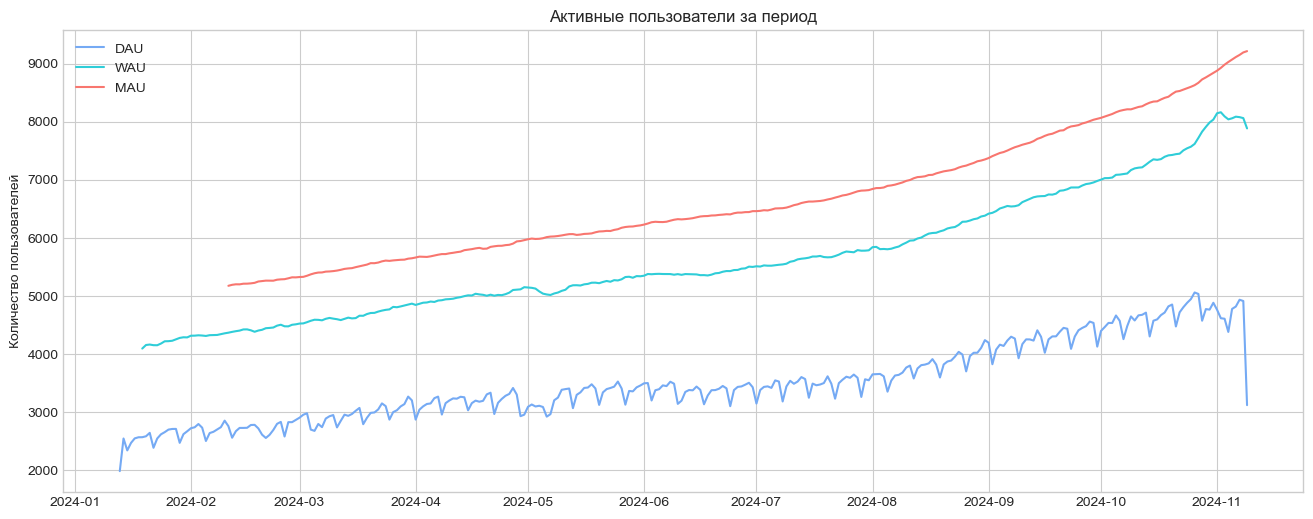

In [697]:
fig, ax = plt.subplots(figsize=(16,6))

sns.lineplot(data=user_activity_metrics, x='date', y='DAU', ax=ax, color="#75AAF4", linewidth=1.5, label='DAU')
sns.lineplot(data=user_activity_metrics, x='date', y='WAU', ax=ax, color="#2FCDD8", linewidth=1.5, label='WAU')
sns.lineplot(data=user_activity_metrics, x='date', y='MAU', ax=ax,  color="#F8766F", linewidth=1.5, label='MAU')

plt.xlabel('')
plt.ylabel('Количество пользователей')
plt.title('Активные пользователи за период')
plt.legend()
plt.show()

**На всех графиках  видно, что с начала года колиество активных пользователей на сервисе постепенно увеличивалось. В ноябре 2024 DAU резко падает, что также отражается и на WAU. Похоже, там что-то случилось. На DAU также заметен повторяющийся недельный паттерн активности пользователей.**

##### 3.2 Расчет количества новых премиум-подписчиков (за неделю и месяц)

In [698]:
weekly_new_subs=df_music_subs.groupby('start_week').uid.nunique().reset_index().rename(columns={'uid':'new_subs_count'})
monthly_new_subs=df_music_subs.groupby('start_month').uid.nunique().reset_index().rename(columns={'uid':'new_subs_count'})

In [699]:
weekly_new_subs.head()

,start_week,new_subs_count
0,2024-01-08,9
1,2024-01-15,49
2,2024-01-22,63
3,2024-01-29,42
4,2024-02-05,57


In [700]:
monthly_new_subs.head()

,start_month,new_subs_count
0,2024-01-01,147
1,2024-02-01,232
2,2024-03-01,272
3,2024-04-01,290
4,2024-05-01,300


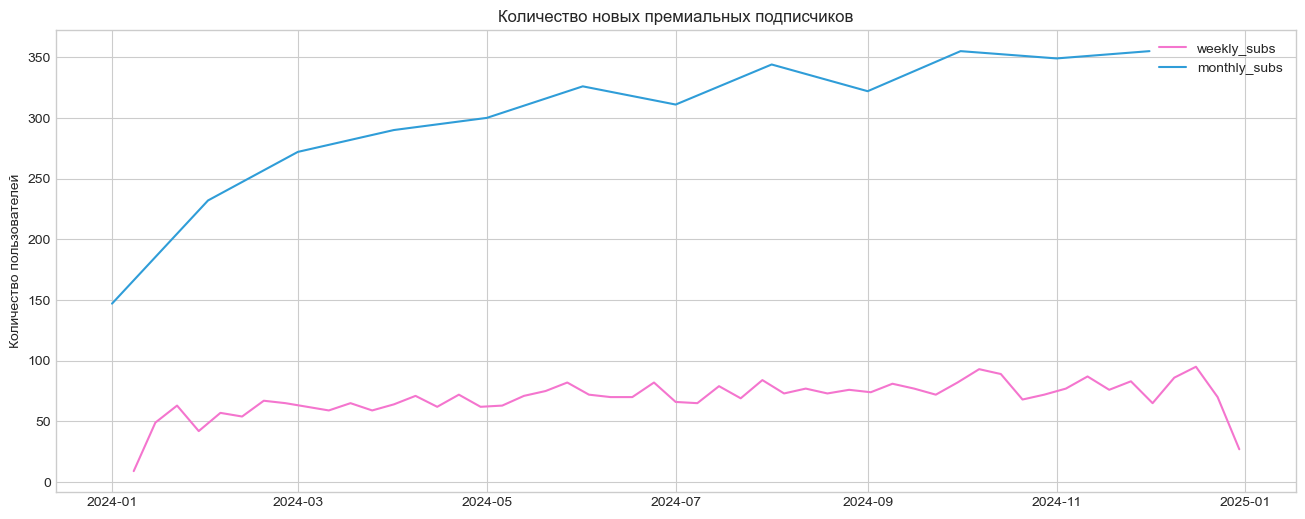

In [701]:
fig, ax = plt.subplots(figsize=(16,6))

sns.lineplot(data=weekly_new_subs, x='start_week', y='new_subs_count', ax=ax, color="#F475CE", linewidth=1.5, label='weekly_subs')
sns.lineplot(data=monthly_new_subs, x='start_month', y='new_subs_count', ax=ax, color="#2F9DD8", linewidth=1.5, label='monthly_subs')

plt.xlabel('')
plt.ylabel('Количество пользователей')
plt.title('Количество новых премиальных подписчиков')
plt.legend()
plt.show()

**Месячный график новых подписчиковимеет восходящий тренд. В целом в течении года недельный график более-менее стабильный в той части, что в неделю подписывается от 50 до 100 подписчиков. Но вот к концу года недельный график быстрее отразил падени в подписках, чем месячный.**

##### 3.3 Расчет проникновения подкастов

In [702]:
# Проникновение подкастов — доля юзеров, послушавших подкаст хотя бы раз (за неделю и месяц). 
# В этом задании нет указания, как именно считать проникновение подскастов, поэтому, считаю пользователей, у которых проставлен content_type=podcast.

# создаю датафрейм для расчета доли пользователей, прослушавших подкаст
df_podcast_logs=df_music_logs.query('content_type=="podcast"')[['week', 'month',  'uid']].drop_duplicates()

In [703]:
weekly_podcast_share=(df_podcast_logs.groupby('week').uid.nunique() / df_music_logs.groupby('week').uid.nunique()["2024-08-26":"2024-11-04"]).round(3).reset_index()\
                        .rename(columns={'uid':'weekly_share'})
weekly_podcast_share.head()

,week,weekly_share
0,2024-08-26,0.029
1,2024-09-02,0.123
2,2024-09-09,0.123
3,2024-09-16,0.142
4,2024-09-23,0.136


In [704]:
monthly_podcast_share=(df_podcast_logs.groupby('month').uid.nunique() / df_music_logs.groupby('month').uid.nunique()["2024-09-01":"2024-11-01"]).round(3).reset_index()\
                        .rename(columns={'uid':'monthly_share'})
monthly_podcast_share.head()

,month,monthly_share
0,2024-09-01,0.286
1,2024-10-01,0.278
2,2024-11-01,0.132


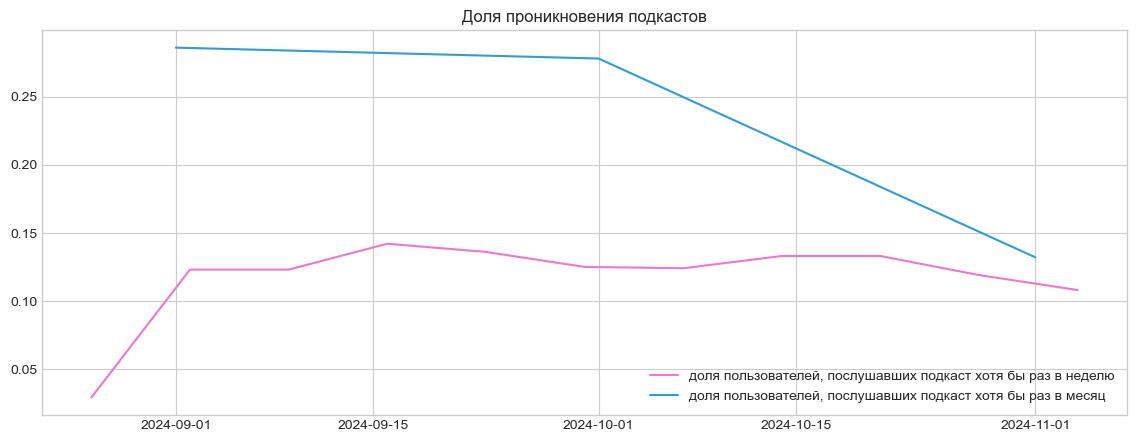

In [705]:
fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(data=weekly_podcast_share, x='week', y='weekly_share', ax=ax, color="#F475CE", linewidth=1.5, label='доля пользователей, послушавших подкаст хотя бы раз в неделю')
sns.lineplot(data=monthly_podcast_share, x='month', y='monthly_share', ax=ax, color="#2F9DD8", linewidth=1.5, label='доля пользователей, послушавших подкаст хотя бы раз в месяц')

plt.xlabel('')
plt.ylabel('')
plt.title('Доля проникновения подкастов')
plt.legend()
plt.show()

**Появления подкастов заинтересовало пользователей, но это доля не значительная, на обоих графиках доля не превышает и половины процента от активной аудитории.**

#### 4. Метрики продукта (шаг 1)  — 2 балла

Рассчитайте и визуализируйте как для всех пользователей в совокупности, так и для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами (грубо говоря разделяем юзеров на тех, кто слушает только музыку и тех, кто слушает еще и подкасты):
1. Среднее время прослушивания на пользователя.
2. Среднее число треков/эпизодов на пользователя (среднее число item_id). Посчитайте метрику, как от уникальных, так и от не уникальных item_id. Подумайте, что показывает каждая из них?
3. Долю премиум-подписчиков. Обратите внимание, что нам нужна активная подписка, если пользователь отписался в том же периоде, что подписался, мы больше не считаем подписку активной.

Рассчитайте и визуализируйте как по всем item_id, так и в разрезе типов контента:
- Долю дослушанных треков/эпизодов до конца. Обратите внимание, данная метрика уже не пользовательская.

Периоды — неделя и месяц. Неполные периоды нужно обрезать, если они мешают чтению графиков.   
Признак взаимодействия присвайвайте только для периода, когда оно действительно было.   
Для месячной динамики метрик по признаку взаимодействия с подкастами у вас получится всего 2 точки, такая визуализая тоже полезна, она сглаживает недельные колебания и помогает оценивать тренд в масштабе года.

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)
- Есть ли отличия между типами контента?

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [706]:
print ('дата начала лога активности:', df_music_logs.date.min()) 
print ('дата конца лога активности:', df_music_logs.date.max()) 
print ('дата начала лога подписки:', df_music_subs.start_date.min()) 
print ('дата конца лога подписки:', df_music_subs.end_date.max()) 

дата начала лога активности: 2024-01-13 00:00:00
дата конца лога активности: 2024-11-09 00:00:00
дата начала лога подписки: 2024-01-13 00:00:00
дата конца лога подписки: 2024-11-09 00:00:00


#### 4.1 Расчет средних метрик продукта

In [707]:
# добавляю колонку с временем прослушивания трэка в минутах
df_music_logs['played_min']=(df_music_logs['played_ratio_pct']*0.01*df_music_logs['track_length_seconds'])/60

In [708]:
df_music_logs.head(3)

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date,date,week,month,played_min
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0,2024-01-13,2024-01-08,2024-01-01,3.750000
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0,2024-01-13,2024-01-08,2024-01-01,4.166667
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0,2024-01-13,2024-01-08,2024-01-01,0.045000


In [709]:
#определяю, кто из пользователей слушал подкаст согласно условию:
df_music_logs['is_listened_podcast']=((df_music_logs['content_type'] == "podcast") & ((df_music_logs['played_min'] > 2) | (df_music_logs['played_ratio_pct'] >= 30))).astype(int)

In [710]:
#отбираю только тех пользователей, которые слушали подкасты, и проставляю флаг пользователям, которые слушали подкасты в течении недели
weekly_podcast_listeners = df_music_logs.query('is_listened_podcast==1')[['week', 'uid']].drop_duplicates()
weekly_podcast_listeners['weekly_podcast_flag']=1
weekly_podcast_listeners.head(3)

,week,uid,weekly_podcast_flag
32526667,2024-08-26,852400,1
32527513,2024-08-26,261000,1
32528143,2024-08-26,11700,1


In [711]:
#аналогично для месяца:
monthly_podcast_listeners = df_music_logs.query('is_listened_podcast==1')[['month', 'uid']].drop_duplicates()
monthly_podcast_listeners['monthly_podcast_flag']=1
monthly_podcast_listeners.head(3)

,month,uid,monthly_podcast_flag
32526667,2024-09-01,852400,1
32527513,2024-09-01,261000,1
32528143,2024-09-01,11700,1


In [712]:
weekly=df_music_logs.query('week>="2024-01-15" and week<"2024-11-04"')\
                    .merge(weekly_podcast_listeners, how='left', on=['week', 'uid'])[['week', 'uid', 'item_id' , 'played_min', 'weekly_podcast_flag']].fillna(0)
weekly.head(3)

,week,uid,item_id,played_min,weekly_podcast_flag
0,2024-01-15,491400,257031,0.520000,0.0
1,2024-01-15,491400,1359763,0.524167,0.0
2,2024-01-15,154600,742446,0.068333,0.0


In [713]:
monthly=df_music_logs.query('month>="2024-02-01" and month<"2024-11-01"')\
                    .merge(monthly_podcast_listeners, how='left', on=['month', 'uid'])[['month', 'uid', 'item_id' , 'played_min', 'monthly_podcast_flag']].fillna(0)
monthly.head(3)

,month,uid,item_id,played_min,monthly_podcast_flag
0,2024-02-01,206900,716679,0.195000,0.0
1,2024-02-01,725800,8451225,3.416667,0.0
2,2024-02-01,646300,1497917,3.000000,0.0


In [714]:
monthly.tail(3)

,month,uid,item_id,played_min,monthly_podcast_flag
42568553,2024-10-01,716800,2601573,3.583333,0.0
42568554,2024-10-01,766400,2682639,4.250000,1.0
42568555,2024-10-01,600,6062462,2.333333,0.0


In [715]:
#функция для расчета средних метрик (времени прослушивания, среднее число уникальных и неуникальных трэков) на пользователя за период:
def metrics_calculation(df, period, flag=None):
    if flag is None:
        user_metrics=df.groupby([period, 'uid']).agg(played_min=('played_min','sum'), unique_item_count=('item_id','nunique'), total_item_count=('item_id','count'))
        metrics_by_user= user_metrics.groupby(period).agg(avg_played_min=('played_min','mean'), avg_unique_items=('unique_item_count','mean'), avg_items=('total_item_count','mean')).reset_index()
    else:
        user_metrics=df.groupby([period, flag, 'uid']).agg(played_min=('played_min','sum'), unique_item_count=('item_id','nunique'), total_item_count=('item_id','count'))
        metrics_by_user= user_metrics.groupby([period, flag]).agg(avg_played_min=('played_min','mean'), avg_unique_items=('unique_item_count','mean'), avg_items=('total_item_count','mean')).reset_index()
        metrics_by_user['flag_value']=metrics_by_user[flag].map({0:'music', 1:'music+podcasts'})
    
    return metrics_by_user

In [716]:
#функция для визуализации метрик:
def metrics_visualisation(df_all, df, x, y, hue_column, title):
    fig, ax = plt.subplots(figsize=(16,4))
    sns.lineplot(data=df_all, x=x, y=y, ax=ax, color="#23EBC3", linewidth=1.5, label='all users')
    sns.lineplot(data=df, x=x, y=y, hue=hue_column, linewidth=1.2, ax=ax)

    legend=ax.legend()
    legend.set_title('Тип пользователя')
    plt.title(title)
    plt.ylabel('')
    plt.xlabel('')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
    plt.show()

In [717]:
#Расчет недельных метрик: 
weekly_product_metrics_all=metrics_calculation(weekly, 'week', flag=None)
weekly_product_metrics_by_flag=metrics_calculation(weekly, 'week', flag='weekly_podcast_flag')

In [718]:
weekly_product_metrics_all.head(3)

,week,avg_played_min,avg_unique_items,avg_items
0,2024-01-15,408.884002,134.139529,182.247358
1,2024-01-22,412.362190,133.240301,183.904068
2,2024-01-29,415.400888,136.248206,186.393841


In [719]:
weekly_product_metrics_by_flag.head(3)

,week,weekly_podcast_flag,avg_played_min,avg_unique_items,avg_items,flag_value
0,2024-01-15,0.0,408.884002,134.139529,182.247358,music
1,2024-01-22,0.0,412.362190,133.240301,183.904068,music
2,2024-01-29,0.0,415.400888,136.248206,186.393841,music


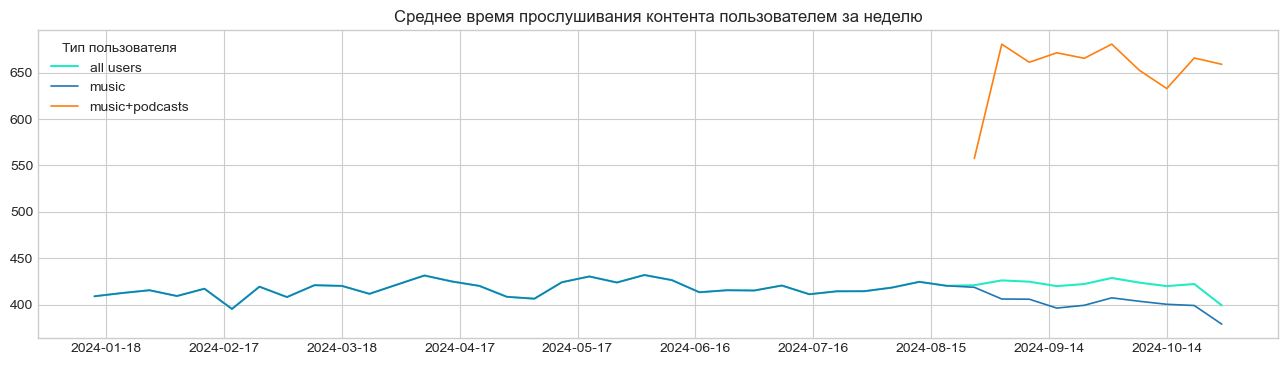

In [720]:
metrics_visualisation(weekly_product_metrics_all, weekly_product_metrics_by_flag, 'week', 'avg_played_min', 'flag_value', 'Среднее время прослушивания контента пользователем за неделю')

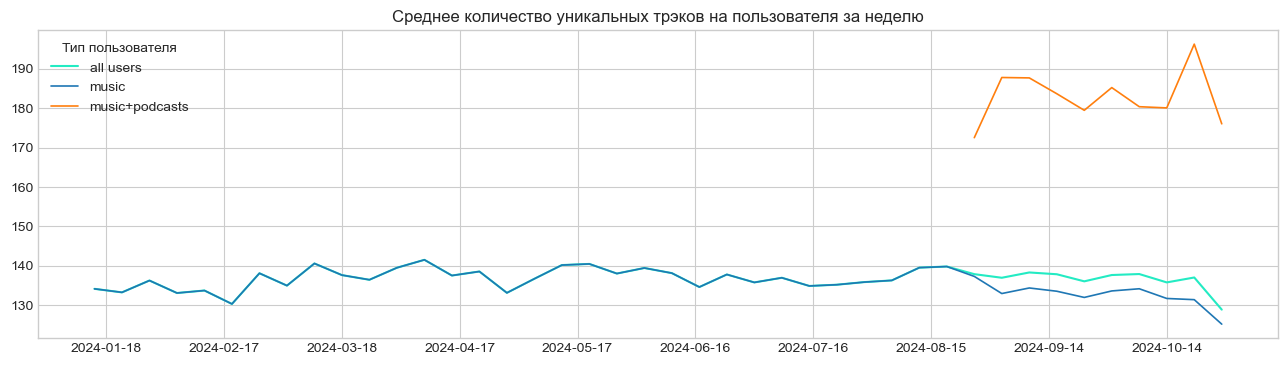

In [721]:
metrics_visualisation(weekly_product_metrics_all, weekly_product_metrics_by_flag, 'week', 'avg_unique_items', 'flag_value', 'Среднее количество уникальных трэков на пользователя за неделю')

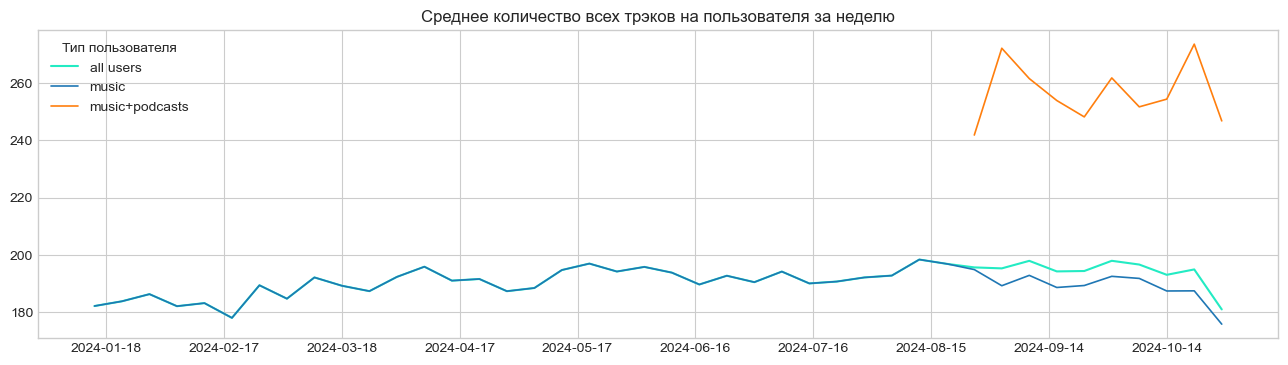

In [722]:
metrics_visualisation(weekly_product_metrics_all, weekly_product_metrics_by_flag, 'week', 'avg_items', 'flag_value', 'Среднее количество всех трэков на пользователя за неделю')

**На недельно период графики для характеристик взаимодействия с подкастами выглядят достаточно волатильными, но в целом можно сказать, что пользователи, взаимодействовавшие с подкастами, имеют более высокие средние значения времени прослушивания и количества прослушанных items, чем пользователи, слушавшие только музыку. Но это наблюдаемое различие не позволяет утверждать, что именно подкасты вызвали более высокую вовлечённость.**

In [723]:
#Расчет месячных метрик: 
monthly_product_metrics_all=metrics_calculation(monthly, 'month', flag=None)
monthly_product_metrics_by_flag=metrics_calculation(monthly, 'month', flag='monthly_podcast_flag')

In [724]:
monthly_product_metrics_all.tail()


,month,avg_played_min,avg_unique_items,avg_items
4,2024-06-01,1518.431987,359.373220,695.950000
5,2024-07-01,1518.798314,358.648597,700.374781
6,2024-08-01,1549.270961,363.654284,721.286605
7,2024-09-01,1519.779167,363.524720,703.548323
8,2024-10-01,1576.550408,376.625141,725.815058


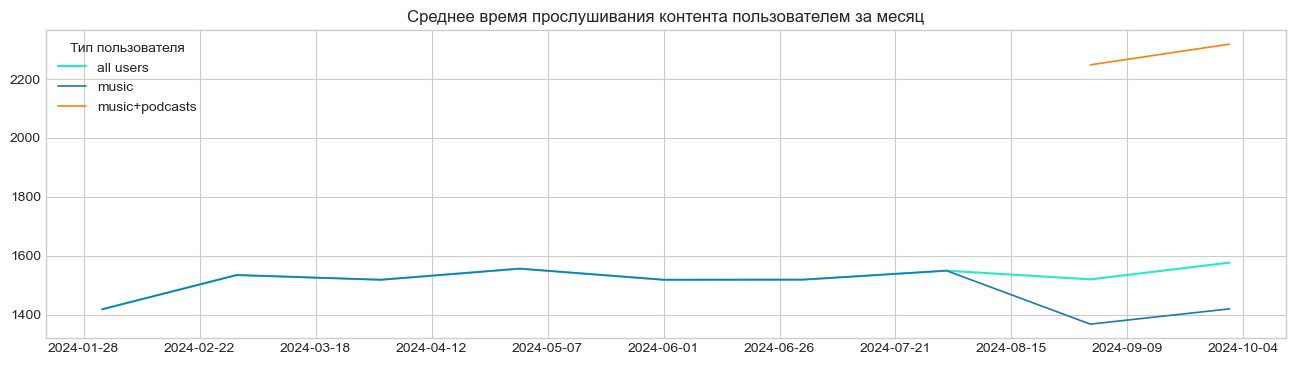

In [725]:
metrics_visualisation(monthly_product_metrics_all, monthly_product_metrics_by_flag, 'month', 'avg_played_min', 'flag_value', 'Среднее время прослушивания контента пользователем за месяц')

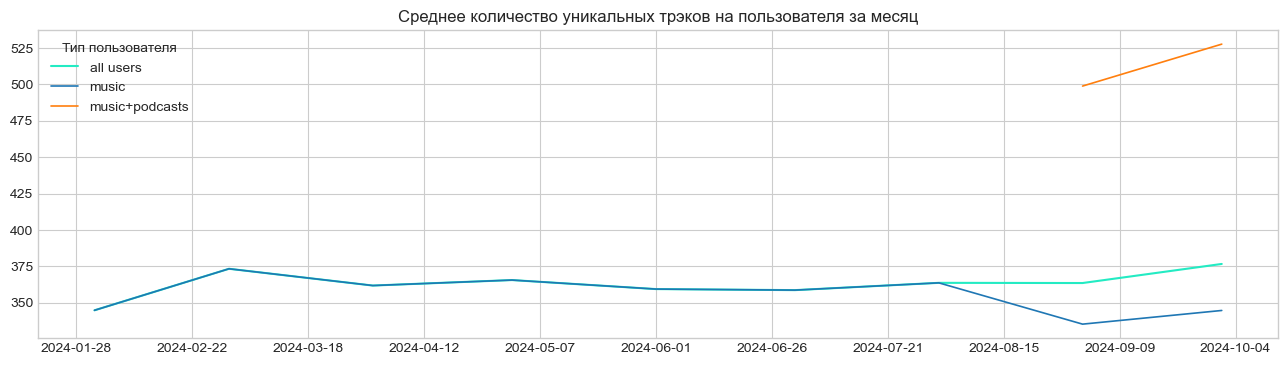

In [726]:
metrics_visualisation(monthly_product_metrics_all, monthly_product_metrics_by_flag, 'month', 'avg_unique_items', 'flag_value', 'Среднее количество уникальных трэков на пользователя за месяц')

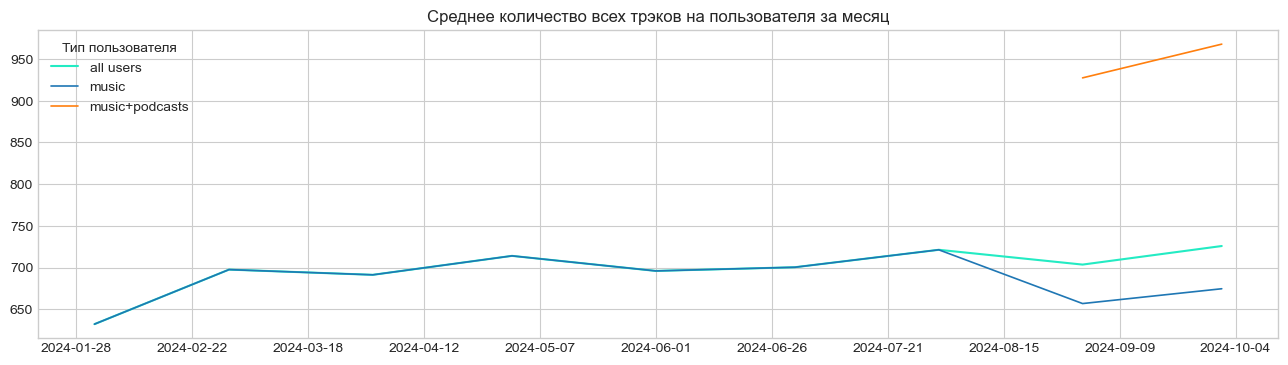

In [727]:
metrics_visualisation(monthly_product_metrics_all, monthly_product_metrics_by_flag, 'month', 'avg_items', 'flag_value', 'Среднее количество всех трэков на пользователя за месяц')

**Вот тут явно заметен восходящий тренд в пользовании подкастами, который вывел и общий график на восходящий тренд.**

#### 4.2 Расчет доли премиальных подписчиков

In [728]:
#подготовка датасета music_subs расчету метрик
df_music_subs.head()

,uid,start_date,end_date,start_week,start_month,end_week,end_month
0,600,2024-08-08,NaT,2024-08-05,2024-08-01,NaT,NaT
1,700,2024-03-29,NaT,2024-03-25,2024-03-01,NaT,NaT
2,800,2024-06-13,NaT,2024-06-10,2024-06-01,NaT,NaT
3,1100,2024-11-19,NaT,2024-11-18,2024-11-01,NaT,NaT
4,1400,2024-12-01,NaT,2024-11-25,2024-12-01,NaT,NaT


In [729]:
#проверка пользователей, которые отписались на той же неделе, что и подписались: 
df_music_subs.query('start_week==end_week')

,uid,start_date,end_date,start_week,start_month,end_week,end_month


In [730]:
#проверка пользователей, которые отписались в том же месяце, что и подписались: 
df_music_subs.query('start_month==end_month') 

,uid,start_date,end_date,start_week,start_month,end_week,end_month


In [731]:
#убираю не полные недели:
premium_weekly=df_music_subs.query('start_week>="2024-01-15" and start_week<"2024-11-04"')[['uid', 'start_week', 'end_week']].copy()

In [732]:
#расчет периода, когда пользователь был премиум подписчиком
premium_weekly['week']=premium_weekly.apply(lambda row: pd.date_range(row['start_week'], row['end_week'] if pd.notna(row['end_week']) else premium_weekly['start_week'].max(), freq='W-MON'), axis=1)
premium_weekly.head(3)

,uid,start_week,end_week,week
0,600,2024-08-05,NaT,"DatetimeIndex(['2024-08-05', '2024-08-12', '20..."
1,700,2024-03-25,NaT,"DatetimeIndex(['2024-03-25', '2024-04-01', '20..."
2,800,2024-06-10,NaT,"DatetimeIndex(['2024-06-10', '2024-06-17', '20..."


In [733]:
premium_weekly=premium_weekly.explode('week')[['uid', 'week']]
premium_weekly['weekly_premium_flag']=1
premium_weekly.head(3)

,uid,week,weekly_premium_flag
0,600,2024-08-05,1
0,600,2024-08-12,1
0,600,2024-08-19,1


In [734]:
premium_monthly=df_music_subs.query('start_month>="2024-02-01" and start_month<"2024-11-01"')[['uid', 'start_month', 'end_month']].copy()
premium_monthly['month']=premium_monthly.apply(lambda row: pd.date_range(row['start_month'], row['end_month'] if pd.notna(row['end_month']) else premium_monthly['start_month'].max(), freq='MS'), axis=1)
premium_monthly=premium_monthly.explode('month')[['uid', 'month']]
premium_monthly['monthly_premium_flag']=1
premium_monthly.head(3)

,uid,month,monthly_premium_flag
0,600,2024-08-01,1
0,600,2024-09-01,1
0,600,2024-10-01,1


In [735]:
weekly_subs_stat=weekly[['week', 'uid', 'weekly_podcast_flag']].drop_duplicates().merge(premium_weekly, how='left', on=['week', 'uid']).fillna(0)
weekly_subs_stat.head(3)

,week,uid,weekly_podcast_flag,weekly_premium_flag
0,2024-01-15,491400,0.0,0.0
1,2024-01-15,154600,0.0,0.0
2,2024-01-15,870900,0.0,0.0


In [736]:
#расчет доли премиальных подписчиков в целом по сервису в разрезе недель:
weekly_premuim_share=(weekly_subs_stat.groupby(['week', 'weekly_premium_flag']).uid.count()/weekly_subs_stat.groupby(['week']).uid.count()).reset_index()
weekly_premuim_share['weekly_premium_flag']=weekly_premuim_share['weekly_premium_flag'].map({0:'non-premium', 1:'premium'})
weekly_premuim_share.rename(columns={'uid':'users_count'}, inplace=True)
weekly_premuim_share.head(3)

,week,weekly_premium_flag,users_count
0,2024-01-15,non-premium,0.988473
1,2024-01-15,premium,0.011527
2,2024-01-22,non-premium,0.974136


In [737]:
#функция для визуализации метрик:
def product_metrics_visualisation(df, x, y, hue_column=None, title=None):

    fig, ax = plt.subplots(figsize=(16,5))
    sns.lineplot(data=df, x=x, y=y, hue=hue_column, color="#23EBC3", linewidth=1.5, ax=ax)
    legend=ax.legend()
    legend.set_title('Тип пользователя')
    plt.title(title)
    plt.ylabel('')
    plt.xlabel('')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
    plt.show()

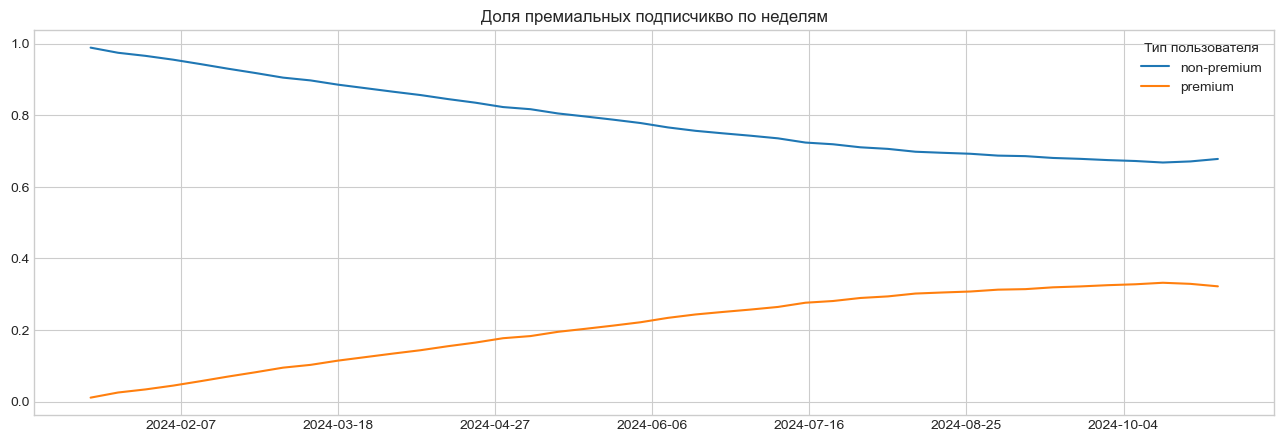

In [738]:
product_metrics_visualisation(weekly_premuim_share, 'week', 'users_count', 'weekly_premium_flag', 'Доля премиальных подписчикво по неделям')

In [739]:
monthly_subs_stat=monthly[['month', 'uid', 'monthly_podcast_flag']].drop_duplicates().merge(premium_monthly, how='left', on=['month', 'uid']).fillna(0)
monthly_subs_stat.head(3)

,month,uid,monthly_podcast_flag,monthly_premium_flag
0,2024-02-01,206900,0.0,0.0
1,2024-02-01,725800,0.0,0.0
2,2024-02-01,646300,0.0,0.0


In [740]:
#расчет доли премиальных подписчиков в целом по сервису в разрезе месяцев:
monthly_premuim_share=(monthly_subs_stat.groupby(['month', 'monthly_premium_flag']).uid.count()/monthly_subs_stat.groupby(['month']).uid.count()).reset_index()
monthly_premuim_share['monthly_premium_flag']=monthly_premuim_share['monthly_premium_flag'].map({0:'non-premium', 1:'premium'})
monthly_premuim_share.rename(columns={'uid':'users_count'}, inplace=True)
monthly_premuim_share.head(3)

,month,monthly_premium_flag,users_count
0,2024-02-01,non-premium,0.956784
1,2024-02-01,premium,0.043216
2,2024-03-01,non-premium,0.913343


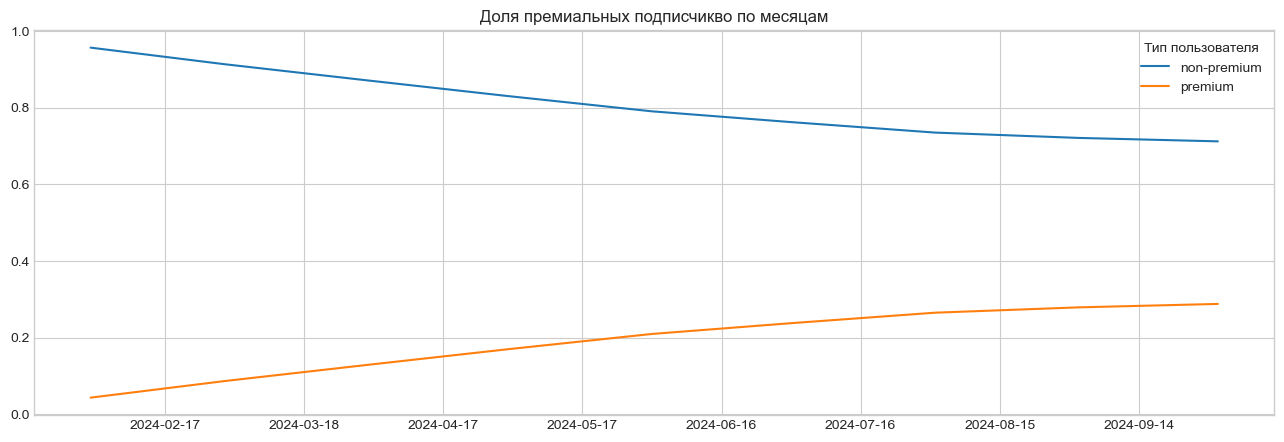

In [741]:
product_metrics_visualisation(monthly_premuim_share, 'month', 'users_count', 'monthly_premium_flag', 'Доля премиальных подписчикво по месяцам')

In [742]:
def define_user_segment(df, period):
    segments=['Music only, non-premium', 'Music + Podcast, non-premium', 'Music only, premium', 'Music + Podcast, premium']
    if period=='week':
        conditions=[(df['weekly_podcast_flag'] == 0) & (df['weekly_premium_flag'] == 0),
                    (df['weekly_podcast_flag'] == 1) & (df['weekly_premium_flag'] == 0),
                    (df['weekly_podcast_flag'] == 0) & (df['weekly_premium_flag'] == 1),
                    (df['weekly_podcast_flag'] == 1) & (df['weekly_premium_flag'] == 1)]
        
    elif period=='month':
        conditions=[(df['monthly_podcast_flag'] == 0) & (df['monthly_premium_flag'] == 0),
                    (df['monthly_podcast_flag'] == 1) & (df['monthly_premium_flag'] == 0),
                    (df['monthly_podcast_flag'] == 0) & (df['monthly_premium_flag'] == 1),
                    (df['monthly_podcast_flag'] == 1) & (df['monthly_premium_flag'] == 1)] 
    else:
        raise ValueError("period must be 'week' or 'month'")
    df['user_segment']=np.select(conditions, segments, default='Unknown')
    return df

In [743]:
weekly_subs_stat=define_user_segment(weekly_subs_stat, 'week')
weekly_subs_stat.head()

,week,uid,weekly_podcast_flag,weekly_premium_flag,user_segment
0,2024-01-15,491400,0.0,0.0,"Music only, non-premium"
1,2024-01-15,154600,0.0,0.0,"Music only, non-premium"
2,2024-01-15,870900,0.0,0.0,"Music only, non-premium"
3,2024-01-15,838300,0.0,0.0,"Music only, non-premium"
4,2024-01-15,354700,0.0,0.0,"Music only, non-premium"


In [744]:
monthly_subs_stat=define_user_segment(monthly_subs_stat, 'month')
monthly_subs_stat.head()

,month,uid,monthly_podcast_flag,monthly_premium_flag,user_segment
0,2024-02-01,206900,0.0,0.0,"Music only, non-premium"
1,2024-02-01,725800,0.0,0.0,"Music only, non-premium"
2,2024-02-01,646300,0.0,0.0,"Music only, non-premium"
3,2024-02-01,632900,0.0,0.0,"Music only, non-premium"
4,2024-02-01,106300,0.0,0.0,"Music only, non-premium"


In [745]:
weekly_subs_metric=weekly_subs_stat.pivot_table(index='week', columns='user_segment', values='uid', aggfunc='count', margins=True, margins_name='All').fillna(0)
weekly_subs_metric=weekly_subs_metric.divide(weekly_subs_metric['All'], axis=0).round(3)
weekly_subs_metric=weekly_subs_metric.iloc[:-1,:-1].stack().reset_index()
weekly_subs_metric=weekly_subs_metric.rename(columns={0:'share'})
weekly_subs_metric.head()

,week,user_segment,share
0,2024-01-15,"Music + Podcast, non-premium",0.000
1,2024-01-15,"Music + Podcast, premium",0.000
2,2024-01-15,"Music only, non-premium",0.988
3,2024-01-15,"Music only, premium",0.012
4,2024-01-22,"Music + Podcast, non-premium",0.000


In [746]:
monthly_subs_metric=monthly_subs_stat.pivot_table(index='month', columns='user_segment', values='uid', aggfunc='count', margins=True, margins_name='All').fillna(0)
monthly_subs_metric=monthly_subs_metric.divide(monthly_subs_metric['All'], axis=0).round(3)
monthly_subs_metric=monthly_subs_metric.iloc[:-1,:-1].stack().reset_index()
monthly_subs_metric=monthly_subs_metric.rename(columns={0:'share'})
monthly_subs_metric.head()

,month,user_segment,share
0,2024-02-01,"Music + Podcast, non-premium",0.000
1,2024-02-01,"Music + Podcast, premium",0.000
2,2024-02-01,"Music only, non-premium",0.957
3,2024-02-01,"Music only, premium",0.043
4,2024-03-01,"Music + Podcast, non-premium",0.000


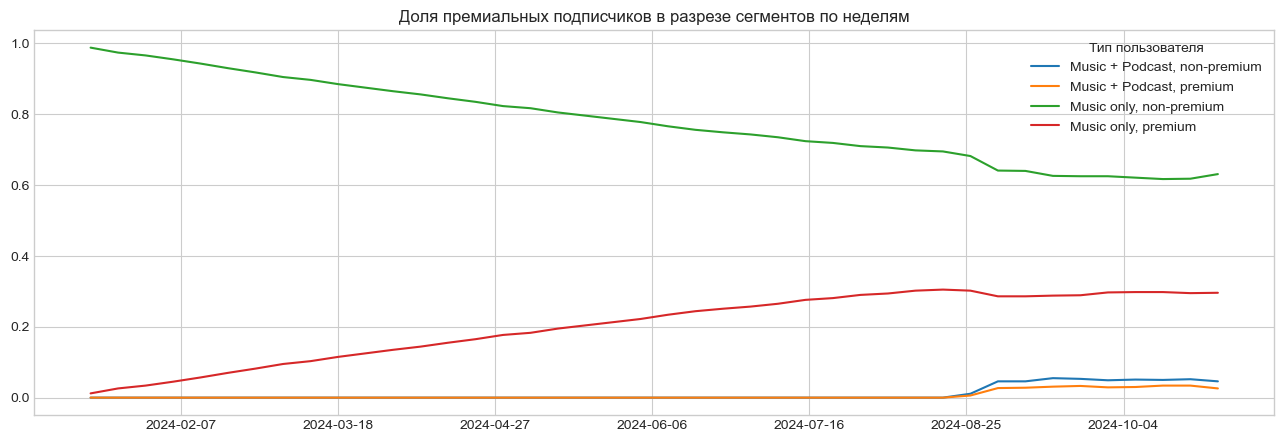

In [747]:
product_metrics_visualisation(weekly_subs_metric, 'week', 'share', 'user_segment', 'Доля премиальных подписчиков в разрезе сегментов по неделям')

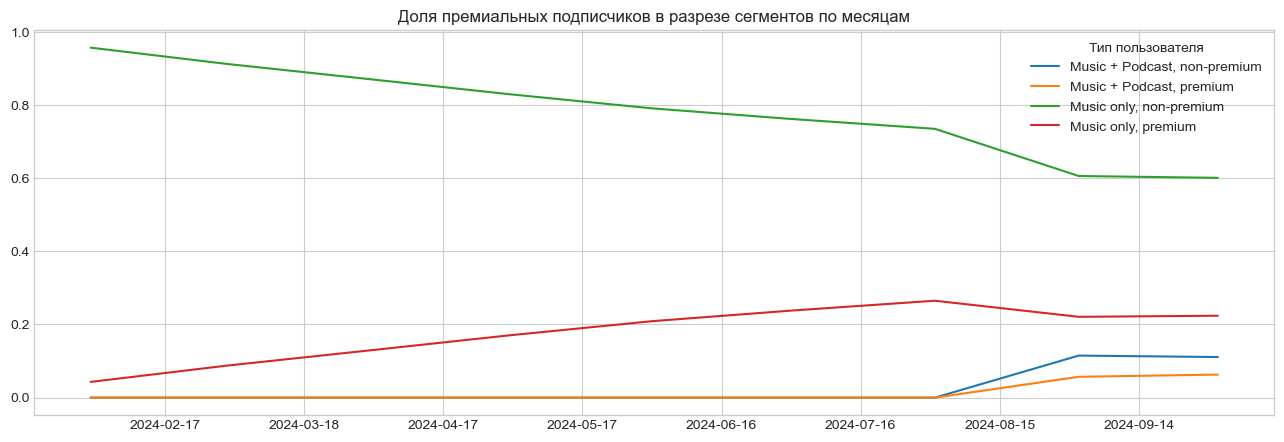

In [748]:
product_metrics_visualisation(monthly_subs_metric, 'month', 'share', 'user_segment', 'Доля премиальных подписчиков в разрезе сегментов по месяцам')

**Выводы** <br>
**Доля премиальных пользователей росла до середины лета, после чего наблюдается снижение. После запуска подкастов общий тренд не показывает резкого изменения, а вот на более детальных графиках видно, что доля premium-пользователей в сегмене music only снижается, а доля сегмента music+podcast начинает расти. И видимо, два этих тренда компенсируют друг друга и поэтому общий тренд остается стабильным.**

##### 4.3 Расчет доли дослушанных трэков до конца

In [749]:
def completed_tracks(df, period, content_type=True):
    if content_type==True:
        completed=df_music_logs.query('played_ratio_pct==100').groupby([period, 'content_type']).item_id.count() 
        all=df_music_logs.groupby([period, 'content_type']).item_id.count()
        completed_share=completed.div(all)

    else:
        completed=df_music_logs.query('played_ratio_pct==100').groupby([period]).item_id.count() 
        all=df_music_logs.groupby([period]).item_id.count()
        completed_share=completed.div(all) 

    if period=='week':
        completed_share=completed_share.loc["2024-01-15":"2024-10-28"].reset_index()

    else:
        completed_share=completed_share.loc["2024-02-01":"2024-10-01"].reset_index()
    
    return completed_share

In [750]:
weekly_completed_by_content=completed_tracks(df_music_logs, 'week', True)
weekly_completed=completed_tracks(df_music_logs, 'week', False)

In [751]:
weekly_completed_by_content.head()

,week,content_type,item_id
0,2024-01-15,music,0.547456
1,2024-01-22,music,0.541428
2,2024-01-29,music,0.539358
3,2024-02-05,music,0.544148
4,2024-02-12,music,0.549772


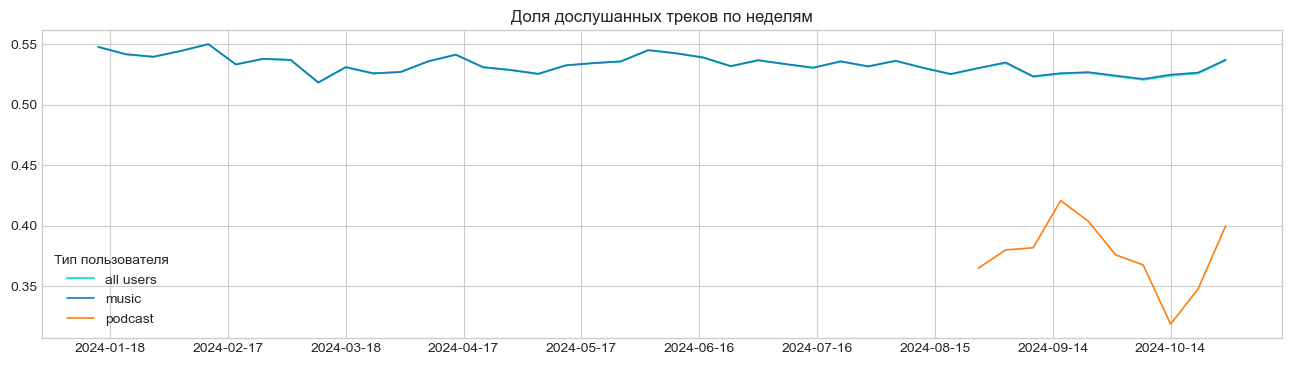

In [752]:
metrics_visualisation(weekly_completed, weekly_completed_by_content, 'week', 'item_id', 'content_type', 'Доля дослушанных треков по неделям')

In [753]:
monthly_completed_by_content=completed_tracks(df_music_logs, 'month', True)
monthly_completed=completed_tracks(df_music_logs, 'month', False)

In [754]:
monthly_completed_by_content.tail()

,month,content_type,item_id
6,2024-08-01,music,0.530753
7,2024-09-01,music,0.526010
8,2024-09-01,podcast,0.398173
9,2024-10-01,music,0.526622
10,2024-10-01,podcast,0.356913


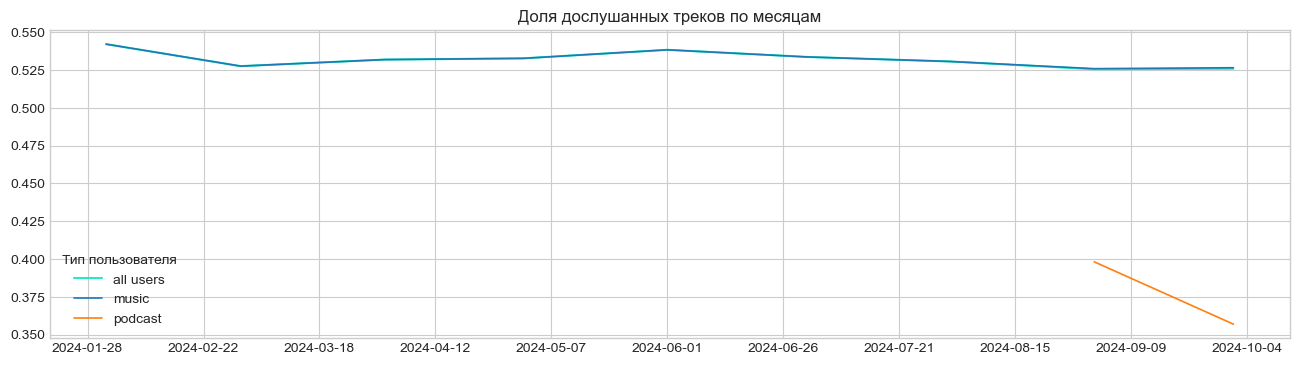

In [755]:
metrics_visualisation(monthly_completed, monthly_completed_by_content, 'month', 'item_id', 'content_type', 'Доля дослушанных треков по месяцам')

**Вывод** <br>
**Поведение пользователей в части дослушивания трэков до конца в разных сегментах отличается. Доля музыки - стабильная, в то время как у подкастов - снижается.** 

#### 5. Метрики продукта (шаг 2)  — 2 балла

Рассчитайте и визуализируйте:
1) D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.
2) D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.
3) D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

Сделайте выводы: 
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [756]:
# your code is here

#формирую датасет для расчета ретеншена:
df_cohort=df_music_logs.groupby(['uid', 'date', 'week', 'month'], as_index=False).agg(is_first_date=('is_first_date', 'max'), is_listened_podcast=('is_listened_podcast', 'max'))
df_cohort.head()

,uid,date,week,month,is_first_date,is_listened_podcast
0,100,2024-01-13,2024-01-08,2024-01-01,0.0,0
1,100,2024-01-14,2024-01-08,2024-01-01,0.0,0
2,100,2024-01-16,2024-01-15,2024-01-01,0.0,0
3,100,2024-01-17,2024-01-15,2024-01-01,0.0,0
4,100,2024-01-25,2024-01-22,2024-01-01,0.0,0


In [757]:
#определяю первый день/неделю/месяц пользователя, на основании которых будет определяться когорта пользователя: 
df_cohort['first_day']=(df_cohort['date'].where (df_cohort['is_first_date']==1)).groupby(df_cohort['uid']).transform('first')
df_cohort['cohort_week']=(df_cohort['week'].where (df_cohort['is_first_date']==1)).groupby(df_cohort['uid']).transform('first')
df_cohort['cohort_month']=(df_cohort['month'].where (df_cohort['is_first_date']==1)).groupby(df_cohort['uid']).transform('first')

In [758]:
#оставляю только тех пользователей, которые присоединились к продукту за период
df_cohort = df_cohort[df_cohort['first_day'].notna()].copy()

In [759]:
df_cohort.head()

,uid,date,week,month,is_first_date,is_listened_podcast,first_day,cohort_week,cohort_month
162,200,2024-06-27,2024-06-24,2024-06-01,1.0,0,2024-06-27,2024-06-24,2024-06-01
163,200,2024-07-22,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
164,200,2024-07-23,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
165,200,2024-07-24,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
166,200,2024-07-26,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01


In [760]:
df_cohort[df_cohort['uid']==171800]

,uid,date,week,month,is_first_date,is_listened_podcast,first_day,cohort_week,cohort_month
177377,171800,2024-03-05,2024-03-04,2024-03-01,1.0,0,2024-03-05,2024-03-04,2024-03-01
177378,171800,2024-03-06,2024-03-04,2024-03-01,0.0,0,2024-03-05,2024-03-04,2024-03-01
177379,171800,2024-03-07,2024-03-04,2024-03-01,0.0,0,2024-03-05,2024-03-04,2024-03-01
177380,171800,2024-03-08,2024-03-04,2024-03-01,0.0,0,2024-03-05,2024-03-04,2024-03-01
177381,171800,2024-03-09,2024-03-04,2024-03-01,0.0,0,2024-03-05,2024-03-04,2024-03-01
...,...,...,...,...,...,...,...,...,...
177454,171800,2024-10-31,2024-10-28,2024-10-01,0.0,1,2024-03-05,2024-03-04,2024-03-01
177455,171800,2024-11-02,2024-10-28,2024-11-01,0.0,0,2024-03-05,2024-03-04,2024-03-01
177456,171800,2024-11-07,2024-11-04,2024-11-01,0.0,1,2024-03-05,2024-03-04,2024-03-01
177457,171800,2024-11-08,2024-11-04,2024-11-01,0.0,1,2024-03-05,2024-03-04,2024-03-01


##### 5.1 D1, D7, D30 retention по всем пользователям. 

In [761]:
##функция для расчета retention:
def calculation_retention(df, day, cohort, retention_name=None):
    df=df.copy()
    #проверка пользователей, которые уже успели достичь нужного дня, чтобы ретеншен расчитался корректно и не показывал 9:
    suitable_date=df['date'].max()-pd.Timedelta(days=day)
    suitable_users=df[[cohort, 'uid', 'first_day']].drop_duplicates().query('first_day <= @suitable_date')

    cohort_user_count=suitable_users.groupby(cohort).uid.nunique()
    returned_users = df[ (df['first_day'] + pd.Timedelta(days=day)) == df['date']]
    returned_user_count = returned_users.groupby(cohort).uid.nunique()
    retention=returned_user_count.div(cohort_user_count).reset_index(name='retention_value')

    if retention_name:
            retention['retention_day']=retention_name

    return retention

In [762]:
retention_D1=calculation_retention(df_cohort, 1, 'cohort_week', 'Day_1')
retention_D7=calculation_retention(df_cohort, 7, 'cohort_week','Day_7')
retention_D30=calculation_retention(df_cohort, 30, 'cohort_week','Day_30')

In [763]:
retention_D1.head()

,cohort_week,retention_value,retention_day
0,2024-01-08,0.743590,Day_1
1,2024-01-15,0.385965,Day_1
2,2024-01-22,0.350515,Day_1
3,2024-01-29,0.356383,Day_1
4,2024-02-05,0.375661,Day_1


In [764]:
#объеденяю все в один датасет для визуализации на одном графике:
retention=pd.concat([retention_D1,retention_D7,retention_D30],ignore_index=True)

In [765]:
retention.head()

,cohort_week,retention_value,retention_day
0,2024-01-08,0.743590,Day_1
1,2024-01-15,0.385965,Day_1
2,2024-01-22,0.350515,Day_1
3,2024-01-29,0.356383,Day_1
4,2024-02-05,0.375661,Day_1


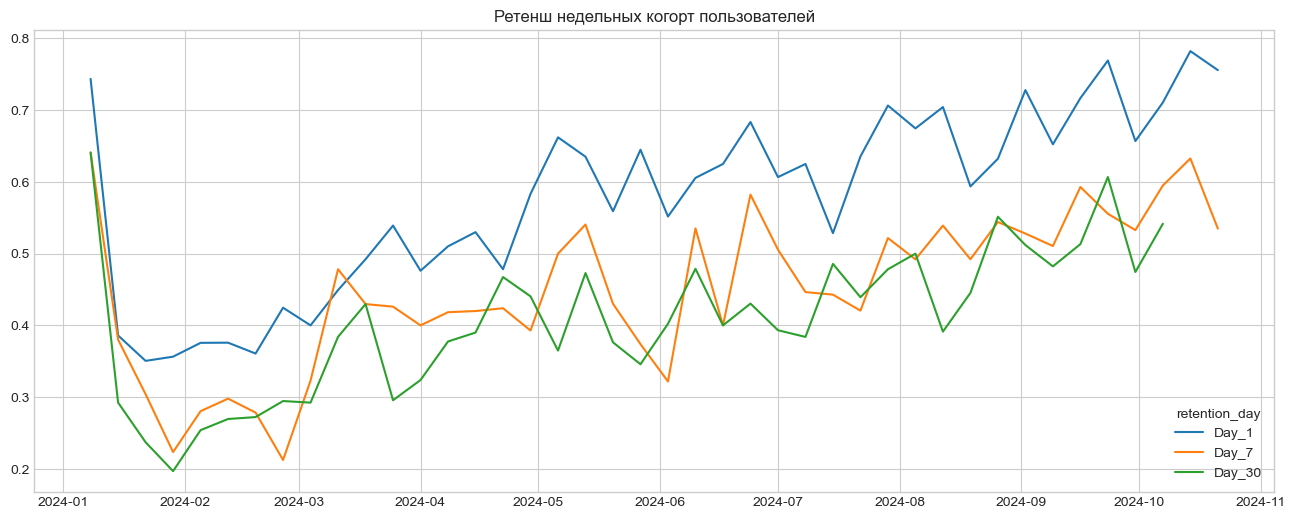

In [766]:
plt.figure(figsize=(16,6))
sns.lineplot(data=retention, x='cohort_week', y='retention_value', hue='retention_day')
plt.xlabel('')
plt.ylabel('')
plt.title('Ретенш недельных когорт пользователей')
plt.show()

##### 5.2 D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. 

Когорты агрегируйте по неделям.

In [767]:
df_cohort.head()

,uid,date,week,month,is_first_date,is_listened_podcast,first_day,cohort_week,cohort_month
162,200,2024-06-27,2024-06-24,2024-06-01,1.0,0,2024-06-27,2024-06-24,2024-06-01
163,200,2024-07-22,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
164,200,2024-07-23,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
165,200,2024-07-24,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01
166,200,2024-07-26,2024-07-22,2024-07-01,0.0,0,2024-06-27,2024-06-24,2024-06-01


In [768]:
def calculation_retention_by_content(df, day, cohort):
    df=df.copy()

    # определяю взаимодействие с подкастом в первые day дней
    df['diff']=(df['date'] - df['first_day']).dt.days
    df_n_days=df[df['diff'].between(0, day)]

    podcast_n_days=df_n_days.groupby('uid')['is_listened_podcast'].max().reset_index().rename(columns={'is_listened_podcast': 'podcast_flag'})
    df=df.merge(podcast_n_days, on='uid', how='left')

    # проверяю какие когорты уже успели достичь нужного дня
    suitable_date=df['date'].max() - pd.Timedelta(days=day)
    suitable_users=df[[cohort, 'uid', 'first_day', 'podcast_flag']].drop_duplicates().query('first_day <= @suitable_date')

    cohort_user_count=suitable_users.groupby([cohort, 'podcast_flag']).uid.nunique()
    returned_users=df[(df['first_day'] + pd.Timedelta(days=day)) == df['date']]

    returned_user_count=returned_users.groupby([cohort, 'podcast_flag']).uid.nunique()
    retention=returned_user_count.div(cohort_user_count).reset_index(name='retention_value')
    
    podcast_flag = {0: 'music', 1: 'music+podcast'}
    retention['user_segment'] = retention['podcast_flag'].map(podcast_flag)

    return retention

In [769]:
content_type_retention_D30=calculation_retention_by_content(df_cohort, 30, 'cohort_week')

In [770]:
content_type_retention_D30.tail()

,cohort_week,podcast_flag,retention_value,user_segment
46,2024-09-23,1,0.655172,music+podcast
47,2024-09-30,0,0.425743,music
48,2024-09-30,1,0.611111,music+podcast
49,2024-10-07,0,0.508772,music
50,2024-10-07,1,0.666667,music+podcast


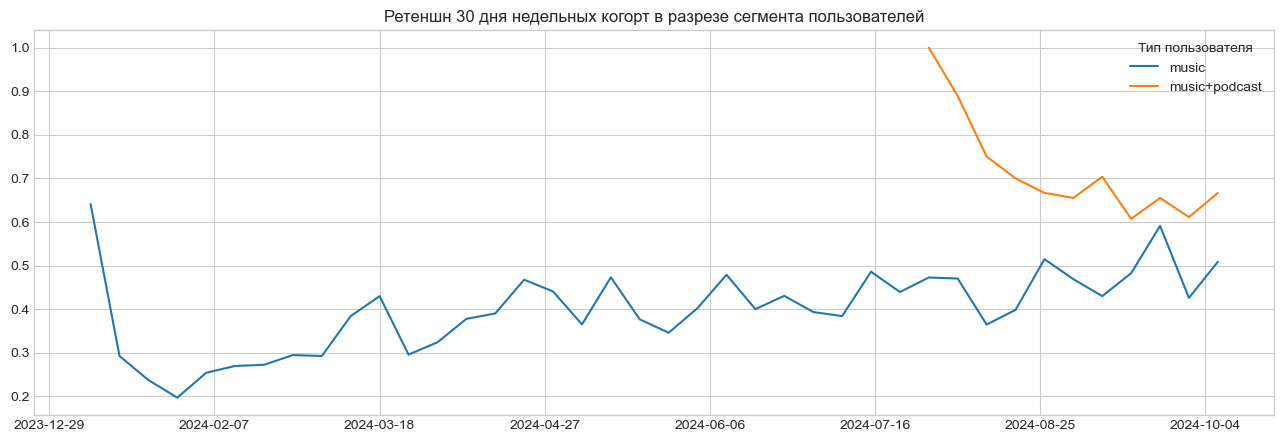

In [771]:
product_metrics_visualisation(content_type_retention_D30, 'cohort_week', 'retention_value', 'user_segment', 'Ретеншн 30 дня недельных когорт в разрезе сегмента пользователей')

##### 5.3 D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. 

Когорты агрегируйте по месяцам.

In [772]:
content_type_retention_D7=calculation_retention_by_content(df_cohort, 7, 'cohort_month')

In [773]:
content_type_retention_D7.tail()

,cohort_month,podcast_flag,retention_value,user_segment
8,2024-08-01,1,0.600000,music+podcast
9,2024-09-01,0,0.525386,music
10,2024-09-01,1,0.645570,music+podcast
11,2024-10-01,0,0.549505,music
12,2024-10-01,1,0.761194,music+podcast


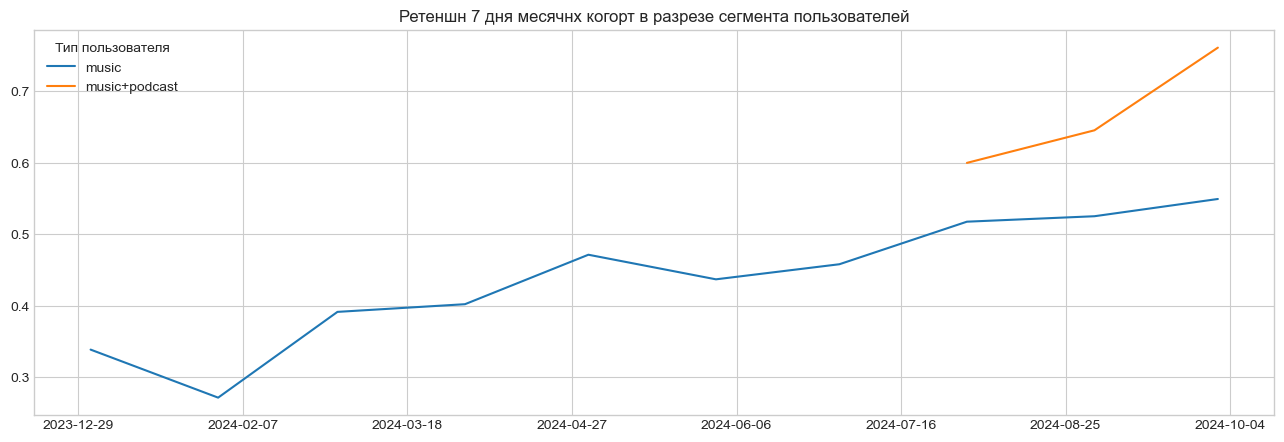

In [774]:
product_metrics_visualisation(content_type_retention_D7, 'cohort_month', 'retention_value', 'user_segment', 'Ретеншн 7 дня месячнх когорт в разрезе сегмента пользователей')

+пункт задания: 
Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

In [775]:
retention_D7=calculation_retention(df_cohort, 7, 'cohort_month')

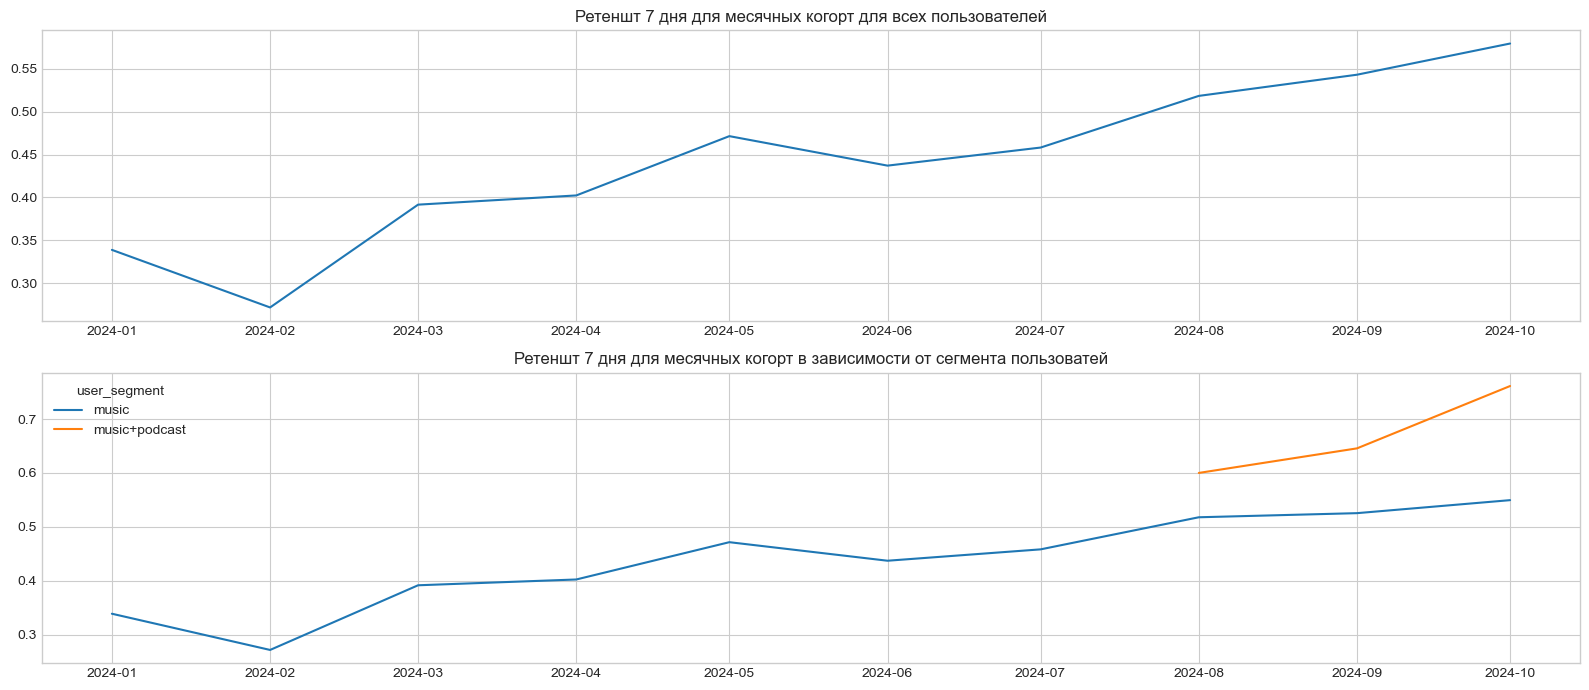

In [776]:
fix, ax=plt.subplots(2,1,figsize=(16,7))
sns.lineplot(retention_D7, x='cohort_month', y='retention_value', ax=ax[0])
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Ретеншт 7 дня для месячных когорт для всех пользователей')
sns.lineplot(data=content_type_retention_D7, x='cohort_month', y='retention_value', hue='user_segment', ax=ax[1])
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_title('Ретеншт 7 дня для месячных когорт в зависимости от сегмента пользоватей')
plt.tight_layout()
plt.show()

Сделайте выводы: 
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)


**Выводы:**

**Графики retention недельных когорот для всех пользователей выглядят волотильными, но в целом как будто бы все виды retention (1, 7 и 30 дня) росли на протяжении года. Хотя мне не совсем понятно падение в начале года (что то не так с расчетом?).** 
** Retention 30 дня с разбивкой по сегмента выглядит более стабильным и на нем видно, что пользователи слушающие в том числе и подкасты иметь чуть более высокий показатель метрики. Тоже самое можно сказать и про retention 7 дня для месячных когорт. На последнем графике, заметно, как значение метрики для пользователей слушающих подкасты подтянули вверх и общий график retention по всем пользователям. В целом же, данных мало и сказать, что ввод подкастов как-то значительно переломил тренд, пока нельзя.

#### 6. Приоритизация метрик  — 2 балла

Составьте список всех метрик, которые были рассчитаны выше (не забудьте, что показатель, рассчитанный в разрезе сегмента — это отдельная метрика). Для простоты давайте ориентироваться только на недельную агрегацию.

1. Присвойте метрикам приоритеты P0-P3 по принципу (в этом пункте стройте приоритизацию на уровне всей компании):
   -  P0 — бизнес результат;
   -  P1 — метрики продукта, напрямую аффектящие бизнес-результат (retention, product as a habit);
   -  P2 — метрики, отражающие взаимодействие пользователя с продуктом (user experience, user engagement) / таргет-метрики отдельных команд продукта;
   -  P3 — метрики стримов / опыт пользователя в рамках работы отдельных команд.
2. Пересоберите приоритеты только для команды подкастов, если цель развития подкастов — рост пользователей с подпиской. Обратите внимание, что вам не нужно отказываться от метрик, рассчитанных по всем пользователям (без сегментов) или для сегмента Music (полезно понимать, не каннибализируем ли мы основной тип контента). Скорее всего приоритеты изменятся только для посегментных метрик.
4. Представьте, что цель внедрения подкастов поменялась — теперь команда в первую очередь хочет задрайвить вовлеченность в продукт. Пересоберите приоритеты при необходимости (в данном пункте могут измениться приоритеты для метрик, рассчитанных по всем пользователям).

Для каждого из пунктов дайте краткое обоснование, почему вы присвоили приоритеты именно так.

**Приоритеты метрик:**

**P0**
- **количество новых премиум-подписчиков**. Я думаю, что эта метрика самая важная для бизнеса, так как она показывает сколько компания зарабатывает на пользоателях. <br>
- **доля премиальных подпискиков среди всех клиетов**. Также важна для бизнеса, чтобы понимать, какую часть аудитории удается конвертировать в платящих пользователей <br>
- **DAU/MAU/WAU**. Я добавила все три метрики, так как, на мой взгляд, для сервиса важно понимать сколько у сервиса активных пользователей на разных периодах и растет ли это число со временем.
- **retention**. Конкретный день, на который смотрит компания, думаю зависит от длительности подписки. Скорее всего тут будет retention 30 дня, так как обычно подписка месячная. И это тоже важный показатель для бизнеса, так как с клиентами, которые постоянно возвращаются, можно отдельно работать для конвертиртации их в премиум-подписки. 
        
**P1**
- **доля премиальных подписчиков в разрезе сегментов пользователей**. Тут уровень продукта, так как сегмент пользователей определеяется потребляемым продуктом сервиса (слушают/не слушают подкасты) и скорее всего в компании за продукты (музыку и подкасты) отвечают разные команды.
- **retention в разрезе сегментов пользователей**. Логика та же, отдельные команды смотрят насколько их продукты вызывают у пользователей желание вернуться к ним через n дней.


**P2**
- **проникновения подкастов**. Важная метрика для команды подкастов, показывает заинтересовались ли пользователи новым типом контента.
- **Среднее время прослушивания, среднее количество прослушанных трэков, среднее количество прослушанных уникальных трэков как общие, так и в разрезе сегментов пользователей** Думаю, что эти метрики также важны отдельным командам для составления потрета их 'среднего/типичного' пользователя, чтобы потом влиять разными предложениями/акциями/улучшениями. А также в случае разных проблем, здесь важно смотреть на поведение среднего пользователя без разделения на сегменты в случае проблема.
- **доля дослушанных уникальных/не уникальных трэков (в разрезе сегментов пользователя и без)**. Думаю, что тут тоже команды смотрят на обе метрики для понимания, где находится их сегмент относительно среднего клиента в компании.

С уровнем P3 немного сложнее, мне кажется в работе у нас нет подходящих метрик для этих уровней. 
Если бы мы рассматривали разные платформы, на которых работает наш стриминговый сервис, например iOS, Android и тд, то можно было бы сюда добавить метрики следующие метрики в разрезе платформ: DAU/MAU/WAU, количество дослушанных трэков, средниее время прослушвивания и пр., чтобы можно было отлавливать проблемы на отдельных платформах. 
 